# Analisis Exploratorio y Limpieza del DataFrame

Primero importamos el dataset


In [221]:
import pandas as pd
from google.colab import drive
from pandas import DataFrame

drive.mount('/content/drive')


df_original = pd.read_csv('/content/drive/MyDrive/almacenesMineria/data_secretariado.csv')
df = df_original.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Contamos el numero de filas de nuestro dataset

In [222]:
print(f"Tamano del dataset: {df.shape}")

num_filas = len(df)
print(f"Numero de filas: {num_filas}")

Tamano del dataset: (133887, 11)
Numero de filas: 133887


Ahora contamos el numero de columnas

In [223]:
columnas = df.columns
print(f"Numero de columnas: {len(columnas)}")


Numero de columnas: 11


## Analisis Exploratorio

### Columna `ORIGEN_REPORTE`

Veamos si la columna contiene datos faltantes en alguna de sus filas:

In [224]:
valores_na_origen_reporte = df['ORIGEN_REPORTE'].isna().sum()
print(f"En total hay {valores_na_origen_reporte} valores nulos en la columna")

En total hay 0 valores nulos en la columna


No hay valores nulos en la columna

Veamos en que instancias se registran a las personas desaparecidas, es decir, veamos los valores distintos de la columna 'ORIGEN_REPORTE'

In [225]:
origen_reportes = df['ORIGEN_REPORTE'].value_counts()
print(f"En total, hay {len(origen_reportes)} fuentes de donde se registran a las personas desaparecidas")
origen_reportes.sort_index(ascending=True)

En total, hay 74 fuentes de donde se registran a las personas desaparecidas


,count
ORIGEN_REPORTE,
COMISION LOCAL DE BUSQUEDA DE PERSONAS DE LA CIUDAD DE MEXICO,722
COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL ESTADO DE AGUASCALIENTES,152
COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL ESTADO DE BAJA CALIFORNIA,1495
COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL ESTADO DE BAJA CALIFORNIA SUR,418
COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL ESTADO DE CAMPECHE,76
...,...
"SUBPROCURADURIA DE CONTROL REGIONAL, PROCEDIMIENTOS PENALES Y AMPARO",1
"SUBPROCURADURIA DE DERECHOS HUMANOS, PREVENCION DEL DELITO Y SERVICIOS A LA COMUNIDAD",1189
"SUBPROCURADURIA DERECHOS HUMANOS, ATENCION A VICTIMAS Y SERVICIOS A LA COMUNIDAD",1


### Categorizacion de las fuentes de reporte

Como vimos, hay **74** fuentes de las que provienen los reportes de personas desaparecidas, ahora categoricemos todas las fuentes, esto nos sera util al momento de sacar estadisticas en un futuro, ya que asi podremos hacer analsis sobre cada tipo de las fuentes de los reportes

#### Comisiones Locales de Busqueda

In [226]:
# Filtramos la serie basándonos en si el índice contiene la palabra 'COMISION'
comisiones_locales_busqueda = origen_reportes[origen_reportes.index.str.contains('COMISION')]

print(f"Hay {len(comisiones_locales_busqueda)} comisiones locales de busqueda, 32 son por cada estado de la republica, y 1 es la comision nacional de busqueda")
# comisiones_locales_busqueda

Hay 33 comisiones locales de busqueda, 32 son por cada estado de la republica, y 1 es la comision nacional de busqueda


#### Fiscalias Generales de Justicia

Veamos cuantas Fiscalias generales de justicia hay, es decir, cuantas fuentes de reporte contienen la palabra 'FISCALIA GENERAL DE'

In [227]:
# El símbolo ~ invierte la máscara de True/False
fiscalias_generales = origen_reportes[origen_reportes.index.str.contains('FISCALIA GENERAL DE')]


print(f"Hay {len(fiscalias_generales)} fiscalias generales de justicia, podemos notar que hay estados que no cuentan con su fiscalia")
# fiscalias_generales

Hay 26 fiscalias generales de justicia, podemos notar que hay estados que no cuentan con su fiscalia


#### Procuradurias y Subprocuradurias

In [228]:
procuradurias = origen_reportes[origen_reportes.index.str.contains('PROCURADURIA')]
subprocuradurias = origen_reportes[origen_reportes.index.str.contains('SUBPROCURADURIA')]
procuradurias = procuradurias[~procuradurias.index.str.contains('SUBPROCURADURIA')]
print(f"En total hay {len(procuradurias)} procuradurias y {len(subprocuradurias)} subprocuradurias")

En total hay 7 procuradurias y 5 subprocuradurias


#### Otras fuentes de reporte

In [229]:
# Unimos los índices de todas las categorías ya identificadas
fuentes_ya_clasificadas = (
    comisiones_locales_busqueda.index
    .union(fiscalias_generales.index)
    .union(procuradurias.index)
    .union(subprocuradurias.index)
)

# Nos quedamos con las que NO están en esas categorías
otras_fuentes = origen_reportes[~origen_reportes.index.isin(fuentes_ya_clasificadas)]

print(f"Hay {len(otras_fuentes)} otras fuentes de reporte")
otras_fuentes.sort_index()

Hay 3 otras fuentes de reporte


,count
ORIGEN_REPORTE,
FISCALIA ESPECIAL PARA LOS DELITOS DE VIOLENCIA CONTRA LAS MUJERES Y TRATA DE PERSONAS,68
PORTAL,8659
SE DESCONOCE,574


## Columna Fecha Nacimiento

Primero revisamos cuántos valores nulos, cuántos registros confidenciales y cuántos valores tienen un formato de fecha válido.

In [230]:
fechas_nacimiento = df['FECHA_NACIMIENTO']

valores_nulos = fechas_nacimiento.isna().sum()
valores_confidenciales = fechas_nacimiento.str.contains('CONFIDENCIAL', na=False).sum()
valores_formato_valido = fechas_nacimiento.str.match(r'^\d{4}-\d{2}-\d{2}$', na=False).sum()

print(f"Valores nulos: {valores_nulos}")
print(f"Valores confidenciales: {valores_confidenciales}")
print(f"Valores con formato yyyy-mm-dd: {valores_formato_valido}")

Valores nulos: 28887
Valores confidenciales: 49149
Valores con formato yyyy-mm-dd: 55851


Observamos que la columna contiene valores nulos y también registros marcados como `CONFIDENCIAL`. Además, los valores que corresponden a fechas siguen el formato `yyyy-mm-dd`, lo cual facilitará su conversión posterior a un tipo de dato fecha.

In [231]:
total_registros = len(df)

print(f"Total de registros: {total_registros}")
print(f"Porcentaje de nulos: {valores_nulos / total_registros:.2%}")
print(f"Porcentaje de confidenciales: {valores_confidenciales / total_registros:.2%}")
print(f"Porcentaje con formato yyyy-mm-dd: {valores_formato_valido / total_registros:.2%}")

Total de registros: 133887
Porcentaje de nulos: 21.58%
Porcentaje de confidenciales: 36.71%
Porcentaje con formato yyyy-mm-dd: 41.72%


Con esta revisión preliminar, podemos concluir que la columna `FECHA_NACIMIENTO` presenta valores faltantes y registros no utilizables directamente, como los marcados como confidenciales. Sin embargo, las fechas disponibles mantienen un formato consistente, por lo que más adelante podrán convertirse de manera controlada a un tipo de dato temporal.

### Columna `Sexo`

Primero revisamos si la columna contiene valores nulos y cuántas categorías distintas presenta.

In [232]:
sexo = df['SEXO']

valores_nulos = sexo.isna().sum()
categorias_sexo = sexo.value_counts()

print(f"Valores nulos: {valores_nulos}")
print(f"Cantidad de categorías distintas: {len(categorias_sexo)}")

Valores nulos: 0
Cantidad de categorías distintas: 4


En esta columna no se observan valores nulos. Además, los registros se agrupan en un conjunto reducido de categorías, lo cual facilita su análisis y su posterior uso en estadísticas descriptivas.

In [233]:
categorias_sexo

,count
SEXO,
HOMBRE,64666
CONFIDENCIAL,49149
MUJER,19716
INDETERMINADO,356


A partir de esta revisión, podemos decir que la columna `SEXO` no requiere tratamiento por valores faltantes.

## Columna Fecha Desaparicion

Primero revisamos cuántos valores nulos existen, cuántos registros aparecen como confidenciales y cuántos valores presentan un formato de fecha válido.

In [234]:
fechas_desaparicion = df['FECHA_DESAPARICION'].astype('string')

valores_nulos = fechas_desaparicion.isna().sum()
valores_confidenciales = fechas_desaparicion.str.contains('CONFIDENCIAL', case=False, na=False).sum()
valores_formato_valido = fechas_desaparicion.str.match(r'^\d{4}-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2}$', na=False).sum()

print(f"Valores nulos: {valores_nulos}")
print(f"Valores confidenciales: {valores_confidenciales}")
print(f"Valores con formato yyyy-mm-dd HH:MM:SS: {valores_formato_valido}")

Valores nulos: 8160
Valores confidenciales: 49149
Valores con formato yyyy-mm-dd HH:MM:SS: 76578


En esta columna sí se observan valores nulos. Además, una parte importante de los registros aparece como `CONFIDENCIAL`, por lo que no todos los valores pueden utilizarse directamente en el análisis. Por otra parte, las fechas válidas mantienen un formato consistente de fecha y hora (`yyyy-mm-dd HH:MM:SS`), lo cual facilita su conversión posterior a un tipo de dato temporal.

In [235]:
total_registros = len(df)

print(f"Total de registros: {total_registros}")
print(f"Porcentaje de nulos: {valores_nulos / total_registros:.2%}")
print(f"Porcentaje de confidenciales: {valores_confidenciales / total_registros:.2%}")
print(f"Porcentaje con formato yyyy-mm-dd HH:MM:SS: {valores_formato_valido / total_registros:.2%}")

Total de registros: 133887
Porcentaje de nulos: 6.09%
Porcentaje de confidenciales: 36.71%
Porcentaje con formato yyyy-mm-dd HH:MM:SS: 57.20%


A partir de esta revisión preliminar, podemos decir que la columna `FECHA_DESAPARICION` tiene valores faltantes y registros confidenciales que deberán tratarse antes de su uso analítico. Sin embargo, los valores válidos conservan un formato homogéneo de fecha y hora, por lo que más adelante podrán convertirse de manera controlada a un tipo de dato temporal.

## Columna Fecha Registro

Primero revisamos cuántos valores nulos existen, cuántos registros aparecen como confidenciales y cuántos valores presentan un formato de fecha y hora válido.

In [236]:
fechas_registro = df['FECHA_REGISTRO'].astype('string')

valores_nulos = fechas_registro.isna().sum()
valores_confidenciales = fechas_registro.str.contains('CONFIDENCIAL', case=False, na=False).sum()
valores_formato_valido = fechas_registro.str.match(r'^\d{4}-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2}$', na=False).sum()

print(f"Valores nulos: {valores_nulos}")
print(f"Valores confidenciales: {valores_confidenciales}")
print(f"Valores con formato yyyy-mm-dd HH:MM:SS: {valores_formato_valido}")

Valores nulos: 6097
Valores confidenciales: 49149
Valores con formato yyyy-mm-dd HH:MM:SS: 78641


En esta columna sí se observan valores nulos. Además, una parte importante de los registros aparece como `CONFIDENCIAL`, por lo que no todos los valores pueden utilizarse directamente en el análisis. Por otra parte, los valores válidos mantienen un formato consistente de fecha y hora (`yyyy-mm-dd HH:MM:SS`), lo cual facilita su conversión posterior a un tipo de dato temporal.

In [237]:
total_registros = len(df)

print(f"Total de registros: {total_registros}")
print(f"Porcentaje de nulos: {valores_nulos / total_registros:.2%}")
print(f"Porcentaje de confidenciales: {valores_confidenciales / total_registros:.2%}")
print(f"Porcentaje con formato yyyy-mm-dd HH:MM:SS: {valores_formato_valido / total_registros:.2%}")

Total de registros: 133887
Porcentaje de nulos: 4.55%
Porcentaje de confidenciales: 36.71%
Porcentaje con formato yyyy-mm-dd HH:MM:SS: 58.74%


A partir de esta revisión preliminar, podemos decir que la columna `FECHA_REGISTRO` presenta valores faltantes y registros confidenciales que deberán tratarse antes de su uso analítico. Sin embargo, los valores válidos conservan un formato homogéneo de fecha y hora, por lo que más adelante podrán convertirse de manera controlada a un tipo de dato temporal.

## Columna `Estatus_Victima`

Primero revisamos si la columna contiene valores nulos y cuántas categorías distintas presenta.

In [238]:
estatus_victima = df['ESTATUS_VICTIMA'].astype('string')

valores_nulos = estatus_victima.isna().sum()
categorias_estatus = estatus_victima.value_counts()

print(f"Valores nulos: {valores_nulos}")
print(f"Cantidad de categorías distintas: {len(categorias_estatus)}")

categorias_estatus

Valores nulos: 0
Cantidad de categorías distintas: 3


,count
ESTATUS_VICTIMA,
DESAPARECIDA,79881
CONFIDENCIAL,49149
NO LOCALIZADA,4857


En esta columna no se observan valores nulos. Además, los registros se agrupan en un número reducido de categorías, lo cual facilita su análisis y su posterior uso en estadísticas descriptivas.

A partir de esta revisión, se concluye que la columna `ESTATUS_VICTIMA` no requiere tratamiento por valores faltantes. Sin embargo, sí es importante considerar que una de las categorías corresponde a registros `CONFIDENCIAL`, por lo que su interpretación deberá hacerse con cuidado durante el análisis.

## Columna Clave Entidad

Primero revisamos si la columna contiene valores nulos y cuántas claves de entidad distintas presenta.

In [239]:
clave_entidad = df['CVE_ENT']

valores_nulos = clave_entidad.isna().sum()
claves_entidad = clave_entidad.value_counts().sort_index()

print(f"Valores nulos: {valores_nulos}")
print(f"Cantidad de claves distintas: {len(claves_entidad)}")

Valores nulos: 0
Cantidad de claves distintas: 33


En esta columna no se observan valores nulos. Además, se identifican 33 claves distintas. Al ordenarlas, se observa que aparecen las claves del `1` al `32`, que corresponden a las entidades federativas de México, y también la clave `99`, que representa casos donde la entidad es desconocida o confidencial.

In [240]:
claves_entidad

,count
CVE_ENT,
1,502
2,4478
3,1024
4,135
5,3647
6,1436
7,1678
8,4107
9,6802


A partir de esta revisión, podemos concluir que la columna `CVE_ENT` no requiere tratamiento por valores faltantes. Sin embargo, sí debemos considerar que la clave `99` no corresponde a una entidad federativa específica, por lo que será importante decidir cómo tratarla en análisis geográficos o estadísticos posteriores.

## Columna `Entidad`

Primero revisamos si la columna contiene valores nulos y cuántas entidades distintas presenta.

In [241]:
entidad = df['ENTIDAD'].astype('string')

valores_nulos = entidad.isna().sum()
entidades = entidad.value_counts().sort_index()

print(f"Valores nulos: {valores_nulos}")
print(f"Cantidad de entidades distintas: {len(entidades)}")

Valores nulos: 0
Cantidad de entidades distintas: 33


En esta columna no se observan valores nulos. Además, se identifican 33 valores distintos: las 32 entidades federativas del país y un registro adicional etiquetado como `SE DESCONOCE`.

In [242]:
entidades

,count
ENTIDAD,
AGUASCALIENTES,502
BAJA CALIFORNIA,4478
BAJA CALIFORNIA SUR,1024
CAMPECHE,135
CHIAPAS,1678
CHIHUAHUA,4107
CIUDAD DE MÉXICO,6802
COAHUILA,3647
COLIMA,1436


También se observa que el número de registros etiquetados como `SE DESCONOCE` coincide con la frecuencia de la clave `99` en la columna `CVE_ENT`, lo cual refuerza la consistencia entre ambas variables.

In [243]:
print(f"Registros con 'SE DESCONOCE': {entidades.loc['SE DESCONOCE']}")
print(f"Registros con clave 99 en CVE_ENT: {(df['CVE_ENT'] == 99).sum()}")

Registros con 'SE DESCONOCE': 2953
Registros con clave 99 en CVE_ENT: 2953


A partir de esta revisión, se concluye que la columna `ENTIDAD` no requiere tratamiento por valores faltantes. Sin embargo, el valor `SE DESCONOCE` deberá considerarse de manera especial en análisis geográficos, ya que no representa una entidad federativa específica.

### Columna `CVE_MUNICIPIO`

Primero revisamos si la columna contiene valores nulos, cuántas claves de municipio distintas presenta y cuáles son los valores más altos al ordenar las claves.

In [244]:
clave_municipio = df['CVE_MUN']

valores_nulos = clave_municipio.isna().sum()
claves_municipio = clave_municipio.value_counts().sort_index()

print(f"Valores nulos: {valores_nulos}")
print(f"Cantidad de claves de municipio distintas: {len(claves_municipio)}")

Valores nulos: 0
Cantidad de claves de municipio distintas: 275


In [245]:
claves_municipio.tail()

,count
CVE_MUN,
558,1
563,1
565,8
570,4
999,54547


En esta columna no se observan valores nulos. Además, se identifican múltiples claves de municipio, y al ordenar los valores se observa la presencia de la clave `999`, la cual aparece con una frecuencia considerable dentro del conjunto de datos.

In [246]:
print(f"Registros con clave 999: {(df['CVE_MUN'] == 999).sum()}")

Registros con clave 999: 54547


Debido a que la clave `999` no corresponde al patrón habitual de claves municipales específicas y aparece con una frecuencia alta, es razonable considerar que representa un caso especial dentro del dataset, posiblemente asociado a municipios desconocidos, no identificados o confidenciales. Esta interpretación deberá tomarse con cuidado

A partir de esta revisión, concluimos que la columna `CVE_MUN` no requiere tratamiento por valores faltantes. Sin embargo, la clave `999` deberá analizarse de manera especial en estudios geográficos, ya que probablemente no representa un municipio específico.

### Columna `MUNICIPIO`

Primero revisamos si la columna contiene valores nulos y cuáles son los valores más frecuentes registrados.

In [247]:
municipio = df['MUNICIPIO'].astype('string')

valores_nulos = municipio.isna().sum()
municipios = municipio.value_counts().sort_values(ascending=False)

print(f"Valores nulos: {valores_nulos}")
print(f"Cantidad de municipios distintos: {len(municipios)}")

Valores nulos: 0
Cantidad de municipios distintos: 1554


In [248]:
municipios.head(10)

,count
MUNICIPIO,
CONFIDENCIAL,49149
SE DESCONOCE,5396
TIJUANA,2064
ATLAUTLA,1835
REYNOSA,1716
MATAMOROS,1710
CULIACÁN,1703
NUEVO LAREDO,1550
MAZATLÁN,1257


En esta columna no se observan valores nulos. Sin embargo, los valores más frecuentes corresponden a `CONFIDENCIAL` y `SE DESCONOCE`, lo que indica que una parte importante de los registros no identifica de manera específica el municipio de ocurrencia.

In [249]:
print(f"Registros con 'CONFIDENCIAL': {municipios.loc['CONFIDENCIAL']}")
print(f"Registros con 'SE DESCONOCE': {municipios.loc['SE DESCONOCE']}")
print(f"Suma de ambos: {municipios.loc['CONFIDENCIAL'] + municipios.loc['SE DESCONOCE']}")
print(f"Porcentaje conjunto: {(municipios.loc['CONFIDENCIAL'] + municipios.loc['SE DESCONOCE']) / len(df):.2%}")

Registros con 'CONFIDENCIAL': 49149
Registros con 'SE DESCONOCE': 5396
Suma de ambos: 54545
Porcentaje conjunto: 40.74%


A partir de esta revisión, la columna `MUNICIPIO` no requiere tratamiento por valores faltantes. No obstante, será importante considerar que una proporción considerable de los registros está clasificada como `CONFIDENCIAL` o `SE DESCONOCE`, lo cual limita el detalle geográfico disponible para el análisis.

## Análisis de los registros `CONFIDENCIAL`

Durante la exploración inicial del dataset se observó una cantidad importante de registros marcados como `CONFIDENCIAL` en varias columnas clave. Antes de decidir cómo tratarlos, conviene identificar si esta reserva de información ocurre de forma aislada o si corresponde al mismo bloque de personas a lo largo de distintas variables.

In [250]:
columnas_confidenciales = [
    'FECHA_NACIMIENTO',
    'SEXO',
    'FECHA_DESAPARICION',
    'FECHA_REGISTRO',
    'ESTATUS_VICTIMA',
    'MUNICIPIO'
]

for col in columnas_confidenciales:
    total_conf = (df[col] == 'CONFIDENCIAL').sum()
    print(f"Registros con {col} confidencial: {total_conf}")

Registros con FECHA_NACIMIENTO confidencial: 49149
Registros con SEXO confidencial: 49149
Registros con FECHA_DESAPARICION confidencial: 49149
Registros con FECHA_REGISTRO confidencial: 49149
Registros con ESTATUS_VICTIMA confidencial: 49149
Registros con MUNICIPIO confidencial: 49149


Los conteos anteriores muestran que la frecuencia de `CONFIDENCIAL` es exactamente la misma en todas las columnas analizadas. Esto sugiere la existencia de un subconjunto común de registros censurados.

In [251]:
subconjuntos_confidenciales = {
    col: set(df.loc[df[col] == 'CONFIDENCIAL', 'ID_VICTIMA'])
    for col in columnas_confidenciales
}

base_ids = subconjuntos_confidenciales['FECHA_NACIMIENTO']

print("Los IDs confidenciales coinciden exactamente con los de FECHA_NACIMIENTO?")
for col, ids in subconjuntos_confidenciales.items():
    print(f"{col}: {base_ids == ids}")

Los IDs confidenciales coinciden exactamente con los de FECHA_NACIMIENTO?
FECHA_NACIMIENTO: True
SEXO: True
FECHA_DESAPARICION: True
FECHA_REGISTRO: True
ESTATUS_VICTIMA: True
MUNICIPIO: True


La comparación confirma que se trata del mismo grupo de víctimas en todas las columnas revisadas. En otras palabras, cuando un registro aparece como `CONFIDENCIAL` en una de estas variables, también aparece censurado en las demás. Esto indica que no estamos frente a valores faltantes dispersos, sino ante un bloque consistente de información reservada.

## Construcción de banderas de confidencialidad

Dado que la única variable que todavía aporta información útil dentro de este bloque censurado es `ENTIDAD`, se separarán estos registros en dos grupos: aquellos cuyo estado sí se conoce y aquellos en los que incluso la entidad aparece como `SE DESCONOCE`.

In [252]:
mask_confidencial_total = (df['FECHA_NACIMIENTO'] == 'CONFIDENCIAL').fillna(False)

df['confidencial_con_estado'] = (
        mask_confidencial_total &
        (df['ENTIDAD'] != 'SE DESCONOCE')
).astype(int)

df['confidencial_sin_estado'] = (
        mask_confidencial_total &
        (df['ENTIDAD'] == 'SE DESCONOCE')
).astype(int)

print("Distribución de la confidencialidad:")
print(f"Confidencial con estado conocido: {df['confidencial_con_estado'].sum()}")
print(f"Confidencial sin estado conocido: {df['confidencial_sin_estado'].sum()}")

Distribución de la confidencialidad:
Confidencial con estado conocido: 48565
Confidencial sin estado conocido: 584


Esta clasificación permite distinguir entre registros reservados que aún conservan valor geográfico y registros cuya utilidad analítica es mucho menor.

## Identificación de registros con información mínima

A continuación se aísla el subconjunto más problemático: los registros que son completamente confidenciales y que además no tienen entidad conocida.

In [253]:
confidencial_sin_entidad = df[df['confidencial_sin_estado'] == 1].copy()

print(f"Total de registros confidenciales sin entidad conocida: {len(confidencial_sin_entidad)}")

Total de registros confidenciales sin entidad conocida: 584


In [254]:
confidencial_sin_entidad['ORIGEN_REPORTE'].value_counts().head(10)

,count
ORIGEN_REPORTE,
PORTAL,219
COMISION NACIONAL DE BUSQUEDA DE PERSONAS,50
COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL ESTADO DE NUEVO LEON,34
SE DESCONOCE,29
FISCALIA GENERAL DE SINALOA,27
COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL ESTADO DE SAN LUIS POTOSI,23
COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL ESTADO DE MEXICO,19
FISCALIA GENERAL DE NAYARIT,19
FISCALIA GENERAL DE OAXACA,18


Aunque estos registros no contienen información demográfica ni de ubicación específica, todavía podrían conservar valor administrativo si al menos se conoce la institución que levantó el reporte. Por ello, se revisa cuántos de ellos también tienen `ORIGEN_REPORTE = 'SE DESCONOCE'`.

In [255]:
df_casos_informacion_minima = confidencial_sin_entidad[
    confidencial_sin_entidad['ORIGEN_REPORTE'] == 'SE DESCONOCE'
    ].copy()

cantidad_informacion_minima = len(df_casos_informacion_minima)
porcentaje_informacion_minima = (cantidad_informacion_minima / len(df)) * 100

print(f"Registros con información mínima: {cantidad_informacion_minima}")
print(f"Esto representa el {porcentaje_informacion_minima:.2f}% del dataset total.")

Registros con información mínima: 29
Esto representa el 0.02% del dataset total.


El resultado muestra que los casos con información realmente mínima son muy pocos en comparación con el tamaño total del dataset. Por ello, conviene tratarlos como un subconjunto muy específico y no confundirlos con todo el bloque confidencial.

## Eliminación de registros con información mínima

Dado que estos registros presentan `CONFIDENCIAL` en todas las variables sensibles analizadas y además tienen `ENTIDAD = 'SE DESCONOCE'` y `ORIGEN_REPORTE = 'SE DESCONOCE'`, su utilidad analítica es prácticamente nula. En consecuencia, se eliminarán del dataset de trabajo, ya que no aportan información demográfica, temporal, geográfica ni institucional aprovechable para el análisis.

In [256]:
mask_informacion_minima = (
        mask_confidencial_total &
        (df['ENTIDAD'] == 'SE DESCONOCE') &
        (df['ORIGEN_REPORTE'] == 'SE DESCONOCE')
)

print(f"Registros a eliminar: {mask_informacion_minima.sum()}")

Registros a eliminar: 29


In [257]:
df = df.loc[~mask_informacion_minima].copy()

print(f"Filas restantes después de eliminar registros con información mínima: {len(df)}")

Filas restantes después de eliminar registros con información mínima: 133858


A partir de este punto, el DataFrame `df` será el dataset principal de trabajo. Es decir, conservará tanto los registros completos como aquellos confidenciales que todavía contienen alguna información útil, y únicamente excluirá los casos con información mínima.

In [258]:
df.head()

,ID_VICTIMA,ORIGEN_REPORTE,FECHA_NACIMIENTO,SEXO,FECHA_DESAPARICION,FECHA_REGISTRO,ESTATUS_VICTIMA,CVE_ENT,ENTIDAD,CVE_MUN,MUNICIPIO,confidencial_con_estado,confidencial_sin_estado
0,D49C001E-41E4-45B7-B8FD-D867578F093E,FISCALIA GENERAL DE DURANGO,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,10,DURANGO,999,CONFIDENCIAL,1,0
1,2D2B5CD4-7AF7-48C3-887E-72F4C6403863,COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL EST...,1971-06-13,HOMBRE,2025-09-28 04:40:00,2025-09-29 10:00:00,DESAPARECIDA,25,SINALOA,4,CONCORDIA,0,0
2,6AE9098C-0C30-4709-9A2C-37F6312CD43E,PROCURADURIA GENERAL DE JUSTICIA DE LA CIUDAD ...,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,9,CIUDAD DE MÉXICO,999,CONFIDENCIAL,1,0
3,6B899D2D-F33D-4880-82CD-953FF972B9C3,FISCALIA GENERAL DEL ESTADO BAJA CALIFORNIA,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,2,BAJA CALIFORNIA,999,CONFIDENCIAL,1,0
4,3F026638-8169-4CEA-9D9A-E345B6D2D7B6,FISCALIA GENERAL DEL ESTADO BAJA CALIFORNIA,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,2,BAJA CALIFORNIA,999,CONFIDENCIAL,1,0


# Limpieza de Datos

A partir de este punto se trabaja con el DataFrame `df` ya depurado de los registros con información mínima. El objetivo de esta sección es construir dos versiones finales del dataset: una general, que conserva los registros confidenciales útiles, y otra temporal, enfocada exclusivamente en análisis cronológicos.

## Preparación base del dataset

#### 1.Valores faltantes

En esta etapa se resume el tratamiento de los valores faltantes reales del dataset. Es importante distinguirlos de los valores `CONFIDENCIAL`, ya que estos últimos no representan ausencia de información, sino información reservada.

In [259]:
resumen_faltantes = pd.DataFrame({
    'columna': ['FECHA_NACIMIENTO', 'FECHA_DESAPARICION', 'FECHA_REGISTRO'],
    'nulos': [
        df['FECHA_NACIMIENTO'].isna().sum(),
        df['FECHA_DESAPARICION'].isna().sum(),
        df['FECHA_REGISTRO'].isna().sum()
    ]
})

resumen_faltantes['porcentaje'] = (resumen_faltantes['nulos'] / len(df) * 100).round(2)
resumen_faltantes['decision'] = [
    'Se conserva como nulo; no se imputa',
    'Se conserva como nulo; no se imputa',
    'Se conserva como nulo; no se imputa'
]

resumen_faltantes

,columna,nulos,porcentaje,decision
0,FECHA_NACIMIENTO,28887,21.58,Se conserva como nulo; no se imputa
1,FECHA_DESAPARICION,8160,6.10,Se conserva como nulo; no se imputa
2,FECHA_REGISTRO,6097,4.55,Se conserva como nulo; no se imputa


Los valores faltantes se conservaron como nulos y no fueron imputados, ya que en este trabajo interesa preservar la información original del registro. La imputación podría introducir supuestos difíciles de justificar, especialmente en variables temporales.

#### 2. Duplicados

Para detectar duplicados se utilizaron dos criterios: duplicados exactos por fila completa y duplicados en el identificador `ID_VICTIMA`, que funciona como clave de registro.

In [260]:
duplicados_fila_completa = df.duplicated().sum()
duplicados_id = df['ID_VICTIMA'].duplicated().sum()

print(f"Duplicados por fila completa: {duplicados_fila_completa}")
print(f"Duplicados en ID_VICTIMA: {duplicados_id}")

Duplicados por fila completa: 0
Duplicados en ID_VICTIMA: 0


No se identificaron registros duplicados bajo ninguno de los dos criterios, por lo que no fue necesario eliminar observaciones por duplicidad.

#### 3. Tipos de Datos Correctos

En esta etapa se corrigen y validan los tipos de datos del dataset principal. Para ello, primero se convierten las claves numéricas, después las variables textuales y, finalmente, se reconstruyen las banderas auxiliares de confidencialidad que serán útiles en las versiones finales del dataset.

##### 3.1 Conversión de variables numéricas

Las columnas `CVE_ENT` y `CVE_MUN` representan claves geográficas, por lo que deben tratarse como variables numéricas enteras. Para conservar posibles valores faltantes, se utiliza el tipo nullable `Int64` de pandas.

In [261]:
df['CVE_ENT'] = pd.to_numeric(df['CVE_ENT'], errors='coerce').astype('Int64')
df['CVE_MUN'] = pd.to_numeric(df['CVE_MUN'], errors='coerce').astype('Int64')

df[['CVE_ENT', 'CVE_MUN']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 133858 entries, 0 to 133886
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   CVE_ENT  133858 non-null  Int64
 1   CVE_MUN  133858 non-null  Int64
dtypes: Int64(2)
memory usage: 3.3 MB


Con esta conversión, ambas columnas quedan preparadas para análisis numéricos, cruces geográficos y validaciones de consistencia entre claves y etiquetas textuales.

##### 3.2 Conversión de variables textuales

Las columnas restantes consideradas en esta etapa contienen identificadores, categorías, nombres institucionales o etiquetas geográficas. Por ello, se convierten explícitamente a tipo `string`, lo que permite un tratamiento uniforme y evita interpretaciones incorrectas por parte de pandas.

In [262]:
columnas_texto = [
    'ID_VICTIMA', 'ORIGEN_REPORTE', 'FECHA_NACIMIENTO', 'SEXO',
    'FECHA_DESAPARICION', 'FECHA_REGISTRO', 'ESTATUS_VICTIMA',
    'ENTIDAD', 'MUNICIPIO'
]

for col in columnas_texto:
    df[col] = df[col].astype('string')

df[columnas_texto].info()

<class 'pandas.core.frame.DataFrame'>
Index: 133858 entries, 0 to 133886
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   ID_VICTIMA          133858 non-null  string
 1   ORIGEN_REPORTE      133858 non-null  string
 2   FECHA_NACIMIENTO    104971 non-null  string
 3   SEXO                133858 non-null  string
 4   FECHA_DESAPARICION  125698 non-null  string
 5   FECHA_REGISTRO      127761 non-null  string
 6   ESTATUS_VICTIMA     133858 non-null  string
 7   ENTIDAD             133858 non-null  string
 8   MUNICIPIO           133858 non-null  string
dtypes: string(9)
memory usage: 10.2 MB


Esta conversión no modifica el contenido semántico de las variables, pero sí asegura consistencia en el manejo de valores categóricos, alfanuméricos y temporales en formato textual.

#### 4. Normalizacion de Categorias

Se aplicó una normalización preventiva sobre las principales columnas categóricas de texto, con el fin de verificar si existían diferencias artificiales por espacios redundantes o por uso inconsistente de mayúsculas y minúsculas. En este caso, no se observaron cambios relevantes, lo que indica que el dataset ya presentaba categorías homogéneas.

In [263]:
columnas_categoricas = ['ORIGEN_REPORTE', 'SEXO', 'ESTATUS_VICTIMA', 'ENTIDAD', 'MUNICIPIO']

for col in columnas_categoricas:
    df[col] = (
        df[col]
        .astype('string')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.upper()
    )

Después de esta revisión, la cardinalidad de las categorías se mantuvo sin cambios, por lo que la normalización funcionó principalmente como una validación preventiva de consistencia.

## Construcción del dataset limpio general (Con datos `CONFIDENCIAL`)

In [264]:
df_limpio_general = df.copy()

df_limpio_general['FECHA_NACIMIENTO_DT'] = pd.to_datetime(
    df_limpio_general['FECHA_NACIMIENTO'],
    format='%Y-%m-%d',
    errors='coerce'
)

df_limpio_general['FECHA_DESAPARICION_DT'] = pd.to_datetime(
    df_limpio_general['FECHA_DESAPARICION'],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

df_limpio_general['FECHA_REGISTRO_DT'] = pd.to_datetime(
    df_limpio_general['FECHA_REGISTRO'],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

print(f"Filas del dataset limpio general: {len(df_limpio_general)}")

Filas del dataset limpio general: 133858


Las nuevas columnas con `_DT` representan la versión temporal limpia de las variables de fecha. Cuando un valor original es `CONFIDENCIAL`, nulo o inválido, su conversión da como resultado `NaT`, que es el valor nulo temporal de pandas.

In [265]:
df_limpio_general[
    ['FECHA_NACIMIENTO_DT', 'FECHA_DESAPARICION_DT', 'FECHA_REGISTRO_DT']
].info()

<class 'pandas.core.frame.DataFrame'>
Index: 133858 entries, 0 to 133886
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   FECHA_NACIMIENTO_DT    55838 non-null  datetime64[ns]
 1   FECHA_DESAPARICION_DT  76578 non-null  datetime64[ns]
 2   FECHA_REGISTRO_DT      78641 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 4.1 MB


## Construcción del dataset limpio temporal (sin datos con fecha `CONFIDENCIAL`)

Para el análisis temporal se construye una segunda versión del dataset excluyendo todo el bloque confidencial. De esta forma, las fechas pueden utilizarse sin ambigüedades en análisis cronológicos.

In [266]:
mask_confidencial_total = (df_limpio_general['FECHA_NACIMIENTO'] == 'CONFIDENCIAL').fillna(False)

df_limpio_temporal = df_limpio_general.loc[~mask_confidencial_total].copy()

print(f"Filas del dataset limpio temporal: {len(df_limpio_temporal)}")

Filas del dataset limpio temporal: 84738


En este dataset temporal se generan banderas que distinguen entre valores originalmente nulos, problemas de conversión y posibles inconsistencias cronológicas.

In [267]:
df_limpio_temporal['nulo_fecha_nacimiento'] = df_limpio_temporal['FECHA_NACIMIENTO'].isna().astype(int)
df_limpio_temporal['nulo_fecha_desaparicion'] = df_limpio_temporal['FECHA_DESAPARICION'].isna().astype(int)
df_limpio_temporal['nulo_fecha_registro'] = df_limpio_temporal['FECHA_REGISTRO'].isna().astype(int)

df_limpio_temporal[
    ['nulo_fecha_nacimiento', 'nulo_fecha_desaparicion', 'nulo_fecha_registro']
].sum()

,0
nulo_fecha_nacimiento,28887
nulo_fecha_desaparicion,8160
nulo_fecha_registro,6097


##### 5. Validacion

Una vez corregidos los tipos de datos y normalizadas las categorías, se realizaron validaciones para identificar inconsistencias estructurales y temporales en las versiones finales del dataset.

##### 5.1 Validaciones estructurales

Primero se verifica la coherencia entre la clave numérica de entidad y la etiqueta textual correspondiente. En particular, se revisa que la clave `99` coincida con el valor `SE DESCONOCE` en la columna `ENTIDAD`.

In [268]:
inconsistencia_entidad = (
        ((df_limpio_general['CVE_ENT'] == 99) & (df_limpio_general['ENTIDAD'] != 'SE DESCONOCE')) |
        ((df_limpio_general['CVE_ENT'] != 99) & (df_limpio_general['ENTIDAD'] == 'SE DESCONOCE'))
).sum()

print(f"Inconsistencias entre CVE_ENT y ENTIDAD: {inconsistencia_entidad}")

Inconsistencias entre CVE_ENT y ENTIDAD: 0


La validación anterior permite confirmar que las claves geográficas y sus etiquetas textuales se encuentran alineadas.

##### 5.2 Validaciones de conversión de fechas

En el dataset temporal se revisa si existen valores no nulos que no hayan podido convertirse correctamente a tipo fecha.

In [269]:
df_limpio_temporal['flag_nacimiento_invalido'] = (
        df_limpio_temporal['FECHA_NACIMIENTO'].notna() &
        df_limpio_temporal['FECHA_NACIMIENTO_DT'].isna()
).astype(int)

df_limpio_temporal['flag_desaparicion_invalido'] = (
        df_limpio_temporal['FECHA_DESAPARICION'].notna() &
        df_limpio_temporal['FECHA_DESAPARICION_DT'].isna()
).astype(int)

df_limpio_temporal['flag_registro_invalido'] = (
        df_limpio_temporal['FECHA_REGISTRO'].notna() &
        df_limpio_temporal['FECHA_REGISTRO_DT'].isna()
).astype(int)

df_limpio_temporal[
    ['flag_nacimiento_invalido', 'flag_desaparicion_invalido', 'flag_registro_invalido']
].sum()

,0
flag_nacimiento_invalido,13
flag_desaparicion_invalido,0
flag_registro_invalido,0


Esta revisión muestra si existen errores de formato adicionales una vez excluido el bloque confidencial.

In [270]:
df_limpio_temporal[
    df_limpio_temporal['flag_nacimiento_invalido'] == 1
    ][['ID_VICTIMA', 'FECHA_NACIMIENTO']]

,ID_VICTIMA,FECHA_NACIMIENTO
34823,61D3E4E8-25B5-4A10-A71A-BD50127663C0,1195-09-26
34949,13234756-34F9-4048-AAD9-27FA6052FF9B,1071-02-15
43263,67D406C3-3905-40CC-BB83-1318FA50B417,0976-11-25
48272,4545FDCE-995F-42DC-ADF5-1F5619E17866,1383-05-20
48395,474F2BF7-1ACB-46C1-A54E-A17533204A3C,0999-06-17
49657,81129C51-9D4C-49CB-A011-23AD66FC3A1B,0190-05-10
68300,39BF7FFD-50B3-4F4E-9A4E-AE2201D02F02,0200-03-20
77975,220B056C-7CA5-4E0F-BD7B-2545063BD24C,0199-08-11
94761,B8BB96B2-E8ED-4C06-8F8E-297F54B57347,0985-07-15
94849,BDB2B807-6234-4FA8-80D9-40884E38233B,0992-10-03


##### 5.3 Validaciones de consistencia temporal

Finalmente, se generan banderas para detectar secuencias cronológicas poco probables entre nacimiento, desaparición y registro.

In [271]:
df_limpio_temporal['flag_nacimiento_despues_desaparicion'] = (
        df_limpio_temporal['FECHA_NACIMIENTO_DT'].notna() &
        df_limpio_temporal['FECHA_DESAPARICION_DT'].notna() &
        (df_limpio_temporal['FECHA_NACIMIENTO_DT'] > df_limpio_temporal['FECHA_DESAPARICION_DT'])
).astype(int)

df_limpio_temporal['flag_nacimiento_despues_registro'] = (
        df_limpio_temporal['FECHA_NACIMIENTO_DT'].notna() &
        df_limpio_temporal['FECHA_REGISTRO_DT'].notna() &
        (df_limpio_temporal['FECHA_NACIMIENTO_DT'] > df_limpio_temporal['FECHA_REGISTRO_DT'])
).astype(int)

df_limpio_temporal['flag_registro_antes_desaparicion'] = (
        df_limpio_temporal['FECHA_REGISTRO_DT'].notna() &
        df_limpio_temporal['FECHA_DESAPARICION_DT'].notna() &
        (df_limpio_temporal['FECHA_REGISTRO_DT'] < df_limpio_temporal['FECHA_DESAPARICION_DT'])
).astype(int)

df_limpio_temporal[
    [
        'flag_nacimiento_despues_desaparicion',
        'flag_nacimiento_despues_registro',
        'flag_registro_antes_desaparicion'
    ]
].sum()

,0
flag_nacimiento_despues_desaparicion,96
flag_nacimiento_despues_registro,132
flag_registro_antes_desaparicion,1121


Estas validaciones no implican automáticamente la eliminación de registros, pero sí permiten identificar observaciones que requieren revisión adicional por posible error de captura o por inconsistencias cronológicas.

#### 6. Generación del CSV limpio

Aunque en memoria se conservan columnas temporales de tipo `datetime`, para exportar a CSV las fechas se serializan nuevamente como texto estandarizado. Esto facilita su lectura posterior desde otras herramientas y conserva un formato uniforme.

In [272]:
df_export_general = df_limpio_general.copy()
df_export_temporal = df_limpio_temporal.copy()

# En el dataset general se conservan las fechas originales
# y se agregan versiones limpias serializadas.
df_export_general['FECHA_NACIMIENTO_LIMPIA'] = df_export_general['FECHA_NACIMIENTO_DT'].dt.strftime('%Y-%m-%d')
df_export_general['FECHA_DESAPARICION_LIMPIA'] = df_export_general['FECHA_DESAPARICION_DT'].dt.strftime(
    '%Y-%m-%d %H:%M:%S')
df_export_general['FECHA_REGISTRO_LIMPIA'] = df_export_general['FECHA_REGISTRO_DT'].dt.strftime('%Y-%m-%d %H:%M:%S')

# En el dataset temporal sí se pueden reemplazar, porque ya no tiene confidenciales
df_export_temporal['FECHA_NACIMIENTO'] = df_export_temporal['FECHA_NACIMIENTO_DT'].dt.strftime('%Y-%m-%d')
df_export_temporal['FECHA_DESAPARICION'] = df_export_temporal['FECHA_DESAPARICION_DT'].dt.strftime('%Y-%m-%d %H:%M:%S')
df_export_temporal['FECHA_REGISTRO'] = df_export_temporal['FECHA_REGISTRO_DT'].dt.strftime('%Y-%m-%d %H:%M:%S')

A continuación se seleccionan únicamente las columnas que se conservarán en los archivos finales.

In [273]:
columnas_finales_general = [
    'ID_VICTIMA', 'ORIGEN_REPORTE',
    'FECHA_NACIMIENTO', 'FECHA_NACIMIENTO_LIMPIA',
    'SEXO',
    'FECHA_DESAPARICION', 'FECHA_DESAPARICION_LIMPIA',
    'FECHA_REGISTRO', 'FECHA_REGISTRO_LIMPIA',
    'ESTATUS_VICTIMA',
    'CVE_ENT', 'ENTIDAD', 'CVE_MUN', 'MUNICIPIO',
    'confidencial_con_estado', 'confidencial_sin_estado'
]

columnas_finales_temporal = [
    'ID_VICTIMA', 'ORIGEN_REPORTE', 'FECHA_NACIMIENTO', 'SEXO',
    'FECHA_DESAPARICION', 'FECHA_REGISTRO', 'ESTATUS_VICTIMA',
    'CVE_ENT', 'ENTIDAD', 'CVE_MUN', 'MUNICIPIO',
    'nulo_fecha_nacimiento', 'nulo_fecha_desaparicion', 'nulo_fecha_registro',
    'flag_nacimiento_invalido',
    'flag_nacimiento_despues_desaparicion', 'flag_nacimiento_despues_registro',
    'flag_registro_antes_desaparicion'
]

df_export_general = df_export_general[columnas_finales_general].copy()
df_export_temporal = df_export_temporal[columnas_finales_temporal].copy()

## Exportación de los datasets finales

In [274]:
print("Resumen final:")
print(f"Filas export general: {len(df_export_general)}")
print(f"Filas export temporal: {len(df_export_temporal)}")
print(f"Columnas export general: {df_export_general.shape[1]}")
print(f"Columnas export temporal: {df_export_temporal.shape[1]}")

print("\nValores clave:")
print(f"confidencial_con_estado: {df_export_general['confidencial_con_estado'].sum()}")
print(f"confidencial_sin_estado: {df_export_general['confidencial_sin_estado'].sum()}")
print(f"flag_nacimiento_invalido: {df_export_temporal['flag_nacimiento_invalido'].sum()}")
print(f"flag_registro_antes_desaparicion: {df_export_temporal['flag_registro_antes_desaparicion'].sum()}")

Resumen final:
Filas export general: 133858
Filas export temporal: 84738
Columnas export general: 16
Columnas export temporal: 18

Valores clave:
confidencial_con_estado: 48565
confidencial_sin_estado: 555
flag_nacimiento_invalido: 13
flag_registro_antes_desaparicion: 1121


In [275]:
df_export_general.to_csv('data_secretariado_limpio_general.csv', index=False)
df_export_temporal.to_csv('data_secretariado_limpio_temporal.csv', index=False)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.


Con esto se concluye la etapa de limpieza. A partir de aquí, el análisis puede realizarse sobre dos bases distintas: `df_export_general`, orientada a análisis descriptivos generales, y `df_export_temporal`, enfocada en análisis cronológicos y temporales.

# Analisis de Datos

Como resultado de la etapa de limpieza se generaron dos datasets finales, cada uno orientado a un tipo distinto de análisis. Ambos parten del mismo proceso de depuración, pero fueron construidos con propósitos específicos.

### `df_export_general`

Este dataset corresponde a la versión general limpia del conjunto de datos. Conserva los registros confidenciales que todavía contienen información útil para análisis descriptivos, institucionales o geográficos. Además, incluye las banderas `confidencial_con_estado` y `confidencial_sin_estado`, que permiten distinguir entre registros reservados con entidad conocida y aquellos en los que incluso la entidad federativa se desconoce.

En esta versión se mantienen las columnas originales del dataset, junto con versiones limpias de las fechas, por lo que resulta adecuada para análisis generales donde no necesariamente se requiere trabajar con secuencias temporales completas.

### `df_export_temporal`

Este dataset corresponde a la versión limpia orientada al análisis temporal. A diferencia del dataset general, aquí se excluyen los registros confidenciales, ya que sus fechas no pueden utilizarse de manera confiable en análisis cronológicos.

Además de las variables principales, esta versión incorpora banderas de apoyo como `nulo_fecha_nacimiento`, `nulo_fecha_desaparicion`, `nulo_fecha_registro` y distintas banderas de consistencia temporal. Estas variables permiten identificar valores faltantes y posibles secuencias cronológicas poco plausibles sin eliminar automáticamente los registros.

### Uso de cada dataset en el análisis

A partir de este punto, el análisis del trabajo se apoyará en ambos datasets según el objetivo de cada apartado:

- `df_export_general` se utilizará para análisis descriptivos generales, distribución por entidad, municipio, origen del reporte, estatus de la víctima y presencia de registros confidenciales.
- `df_export_temporal` se utilizará para análisis relacionados con fechas, cronología de registros, consistencia temporal y cualquier exploración que dependa directamente de variables temporales limpias.

In [276]:
print("Resumen final de los datasets generados:")
print(f"df_export_general -> filas: {df_export_general.shape[0]}, columnas: {df_export_general.shape[1]}")
print(f"df_export_temporal -> filas: {df_export_temporal.shape[0]}, columnas: {df_export_temporal.shape[1]}")

Resumen final de los datasets generados:
df_export_general -> filas: 133858, columnas: 16
df_export_temporal -> filas: 84738, columnas: 18


# Cálculo de medidas y visualización

Al tener dos tablas con distinto formato y un objetivo distinto, cambiaremos de tabla si es requerido por la medida evaluada en el momento



### Medidas de localización



#### Moda


Al contar con mayor cantidad de información en `df_export_general`, extraeremos los datos directamente de está tabla para las medidas de localización.
Al hacer el proceso de extracción de los resultados más repetidos en cada una de las columnas, encontramos la moda de cada una de las entradas. Podemos notar que el sexo masculino es el más registrado en los reportes de desaparación, Jalisco es el estado en el que más reportes se generan junto con su procuraduría.
Esto se debe a la alta presencia de grupos delictivos en la zona y los conflictos que son generados gracias a estos.

In [277]:
# Creamos un diccionario con los valores predominantes
datos_moda = {
    "Variable": ["Sexo", "Entidad", "Estatus", "Origen del Reporte"],
    "Valor más frecuente": [
        df_export_general['SEXO'].mode()[0],
        df_export_general['ENTIDAD'].mode()[0],
        df_export_general['ESTATUS_VICTIMA'].mode()[0],
        df_export_general['ORIGEN_REPORTE'].mode()[0]
    ],
    "Número de ocurrencias": [
        df_export_general['SEXO'].value_counts().max(),
        df_export_general['ENTIDAD'].value_counts().max(),
        df_export_general['ESTATUS_VICTIMA'].value_counts().max(),
        df_export_general['ORIGEN_REPORTE'].value_counts().max()
    ],
    "Porcentaje del total de ocurrencias": [
        (df_export_general['SEXO'].value_counts().max() / total_registros) * 100,
        (df_export_general['ENTIDAD'].value_counts().max() / total_registros) * 100,
        (df_export_general['ESTATUS_VICTIMA'].value_counts().max() / total_registros) * 100,
        (df_export_general['ORIGEN_REPORTE'].value_counts().max() / total_registros) * 100
    ]
}
tabla_resumen = pd.DataFrame(datos_moda)
print(tabla_resumen)

             Variable                                Valor más frecuente  \
0                Sexo                                             HOMBRE   
1             Entidad                                            JALISCO   
2             Estatus                                       DESAPARECIDA   
3  Origen del Reporte  PROCURADURIA GENERAL DE JUSTICIA DEL ESTADO DE...   

   Número de ocurrencias  Porcentaje del total de ocurrencias  
0                  64666                            48.298939  
1                  14811                            11.062314  
2                  79881                            59.662999  
3                  12085                             9.026268  


En las siguientes gráficas podemos observar las medidas más contundentes, ya que el porcentaje de hombres desaparecidos respecto al de mujeres es notable; además de la no tan remarcable diferencia entre las entidades federativas con más reportes, ya que las primeras tres presentan la misma problemática de altas tasas de delincuencia-

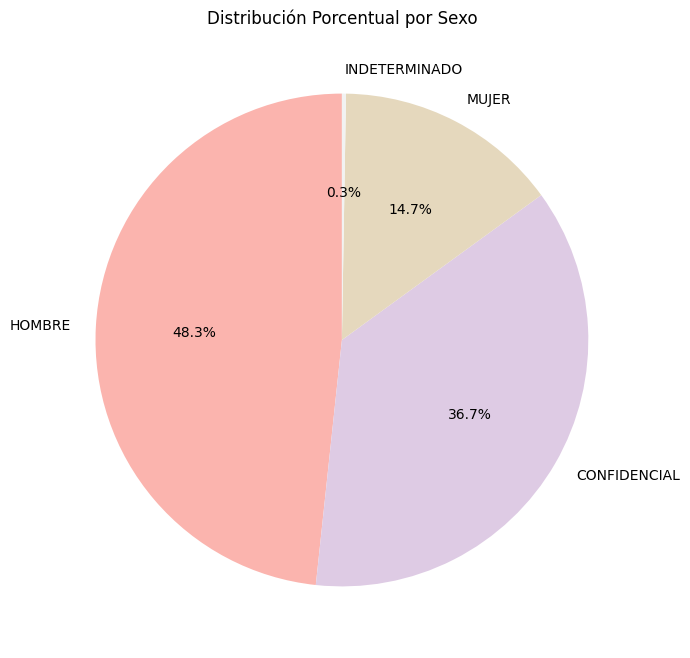

In [278]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
df_export_general['SEXO'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Distribución Porcentual por Sexo')
plt.ylabel('')
plt.show()

/tmp/ipykernel_767/3733724793.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_export_general, y='ENTIDAD',


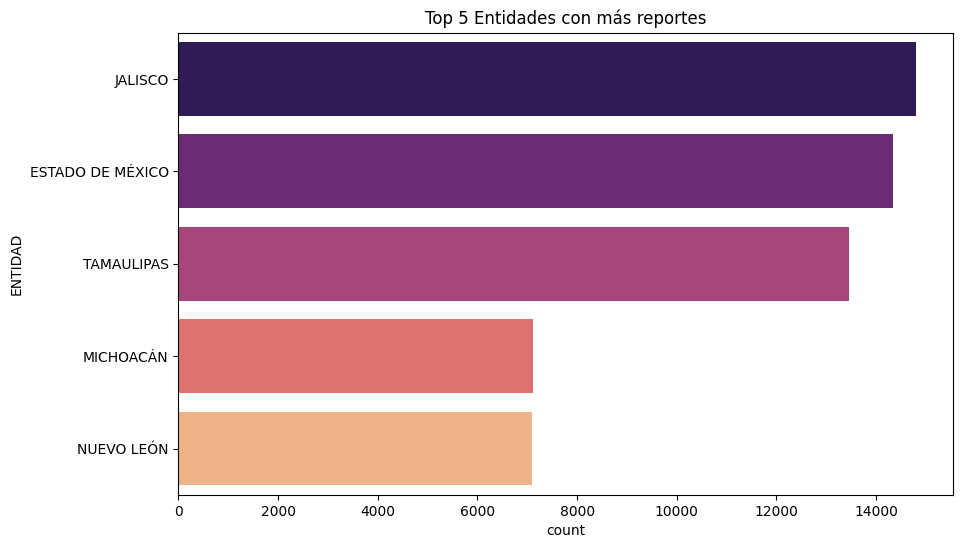

In [279]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.countplot(data=df_export_general, y='ENTIDAD',
              order=df_export_general['ENTIDAD'].value_counts().index[:5],
              palette='magma')
plt.title('Top 5 Entidades con más reportes')
plt.show()

#### Media y Mediana
Al contar con registros fuertemente relacionados al tiempo y necesitar el menor sesgo posible que pueda afectar a nuestros resultados, cambiamos a la tabla `df_export_temporal`

Podemos extraer información relevante de las fechas de nacimiento, como las edades de las personas al momento de su desaparición o el tiempo que transcurrió entre la fecha de la desaparición y la fecha de creación del reporte.







La edad al momento de la desaparición es la resta entre la fecha de desaparición y la fecha de nacimiento, hacemos un pqueños filtrado con unicamente las entradas de fechas válidas, permitiendo eliminar el sesgo de los registros generales sin perder la consistencia.

In [280]:


# Convertimos a datetime solo para el cálculo
fecha_desaparicion_temp = pd.to_datetime(df_export_temporal['FECHA_DESAPARICION'], errors='coerce')
fecha_nacimiento_temp = pd.to_datetime(df_export_temporal['FECHA_NACIMIENTO'], errors='coerce')

edades = (
    fecha_desaparicion_temp.dt.year -
    fecha_nacimiento_temp.dt.year
)

# Filtramos valores nulos (NaT) que pudieron surgir de la conversión y edades irreales
# Nota: Este valor será usado numerosas veces en las siguientes medidas.
edades_validas = edades.dropna()
edades_validas = edades_validas[(edades_validas >= 0) & (edades_validas <= 110)]

# Medidas de Localización
media_e = edades_validas.mean()
mediana_e = edades_validas.median()

print(f"--- Edades al desparecer ---")
print(f"Promedio de edades: {media_e:.2f} años")
print(f"Mediana de edades: {mediana_e:.2f} años")

f_registro_temp = pd.to_datetime(df_export_temporal['FECHA_REGISTRO'], errors='coerce')
f_desaparicion_temp = pd.to_datetime(df_export_temporal['FECHA_DESAPARICION'], errors='coerce')

# 2. Calculamos la diferencia de días en una variable aparte
dias_diferencia = (f_registro_temp - f_desaparicion_temp).dt.days

# Filtramos valores nulos (NaT) que pudieron surgir de la conversión y edades irreales
dias_validos = dias_diferencia[dias_diferencia >= 0].dropna()

# Medidas de Localización
media_tramite = dias_validos.mean()
mediana_tramite = dias_validos.median()

print(f"Días transcurridos entre la desaparición y el registro:")
print(f"Promedio de días: {media_tramite:.2f}")
print(f"Mediana de días: {mediana_tramite}")

--- Edades al desparecer ---
Promedio de edades: 32.34 años
Mediana de edades: 30.00 años
Días transcurridos entre la desaparición y el registro:
Promedio de días: 16.33
Mediana de días: 0.0


No encontramos mucha diferencia entre el promedio de edad entre las personas y su mediana, ya que indican que la edad media de las personas desaparecidas es de un poco más de 30 años; pero el resultado más interesante es el que podemos observar entre el promedio y la mediana entre el tiempo de desaparición y de registro, siendo que una gran cantidad de datos (la mitad inferior por definición de la mediana) indica que el registro se hizo el mismo día que la desaparición, pero la media indica que en algunos casos la espera fue bastante considerable, siendo estos valores atípicos que afectaron nuestros resultados.

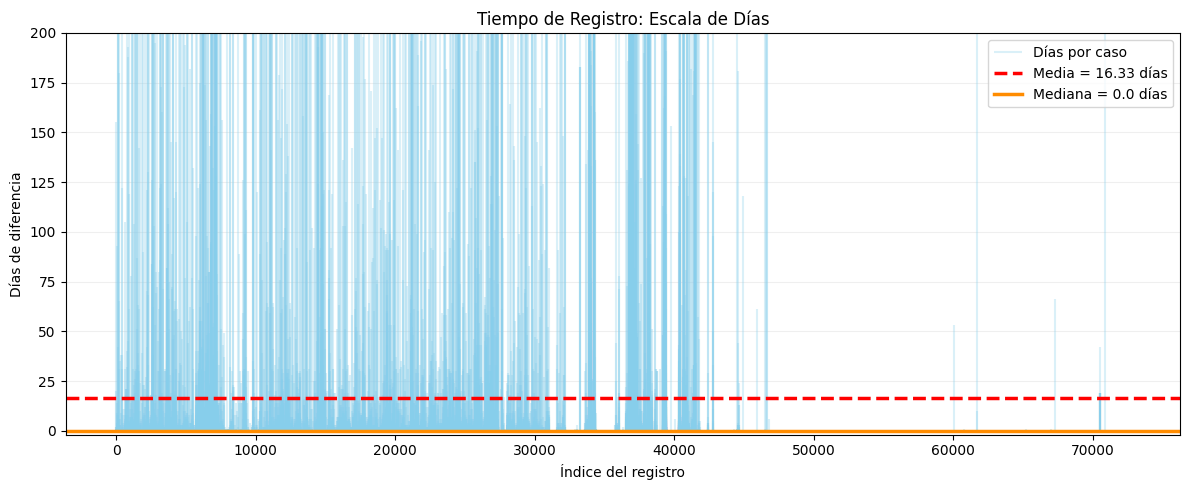

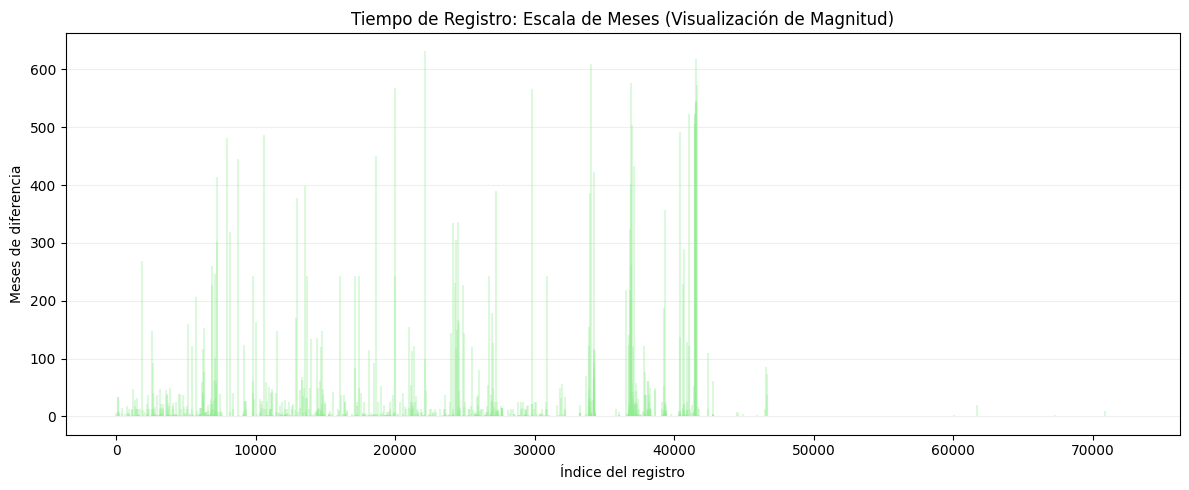

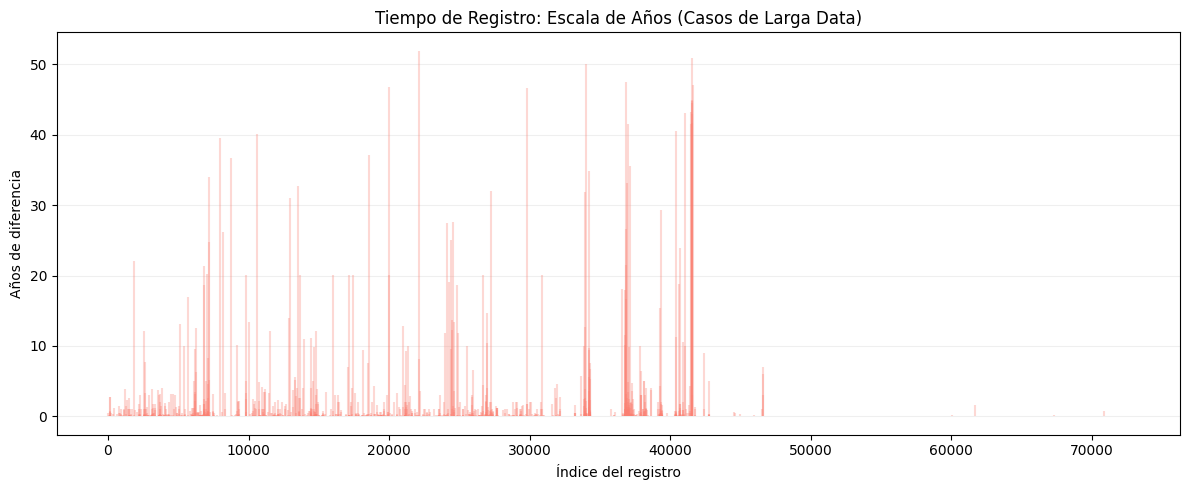

In [281]:
import numpy as np

# Preparación de datos en las tres escalas
y_dias = dias_validos.values
y_meses = y_dias / 30
y_años = y_dias / 365
x_casos = np.arange(len(y_dias))

# --- 1. GRÁFICA EN DÍAS
plt.figure(figsize=(12, 5))
plt.vlines(x_casos, ymin=0, ymax=y_dias, color='skyblue', alpha=0.3, label='Días por caso')

media = y_dias.mean()
mediana = np.median(y_dias)

plt.axhline(media, color="red", linestyle="--", linewidth=2.5,
            label=f"Media = {media:.2f} días")
plt.axhline(mediana, color="darkorange", linestyle="-", linewidth=2.5,
            label=f"Mediana = {mediana:.1f} días")

plt.ylim(-2, 200) # Límite conservado para resaltar el comportamiento base
plt.title("Tiempo de Registro: Escala de Días")
plt.xlabel("Índice del registro")
plt.ylabel("Días de diferencia")
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# --- 2. GRÁFICA EN MESES
plt.figure(figsize=(12, 5))
plt.vlines(x_casos, ymin=0, ymax=y_meses, color='lightgreen', alpha=0.3)
plt.title("Tiempo de Registro: Escala de Meses (Visualización de Magnitud)")
plt.xlabel("Índice del registro")
plt.ylabel("Meses de diferencia")
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# --- 3. GRÁFICA EN AÑOS
plt.figure(figsize=(12, 5))
plt.vlines(x_casos, ymin=0, ymax=y_años, color='salmon', alpha=0.3)
plt.title("Tiempo de Registro: Escala de Años (Casos de Larga Data)")
plt.xlabel("Índice del registro")
plt.ylabel("Años de diferencia")
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

La anterior gráfica muestra el número de días entre el registro y la desaparición, es claro que hay una mayor cantidad de personas que fueron registradas en el mismo días por los vacios entre las barras, pero hay algunos registros con tiempos de espera superiores a varios años. Se incluyen gráficos adicionales con el número de meses y años para poder apreciar mejor el rango entre las fechas.

### Medidas de Variabilidad

#### Rango, IQR, Varianza y Desviación
 En estas mediciones continuaremos lo propuesto en la sección anterior sobre la edad de las personas desaparecidas, en este caso se salteará el análisis de los días de diferencia en registro, ya que la diferencia es lo suficientemente alta como para hacer su análisis completamente impreciso.
El rango es la diferencia entre el valor mínimo y el valor máximo, cómo observamos en las operaciones anteriores encontramos una gran cantidad de valores atípicos que alteran el comportamiento de diversas medidas, incluyendo el rango, el IQR en cambio nos dará información más relevante respecto a la concentración de información: los valores centrales de los registros de edad.



--- Análisis de Variabilidad (Rango e IQR) ---
Rango: 110.00 años
IQR: 18.00 años


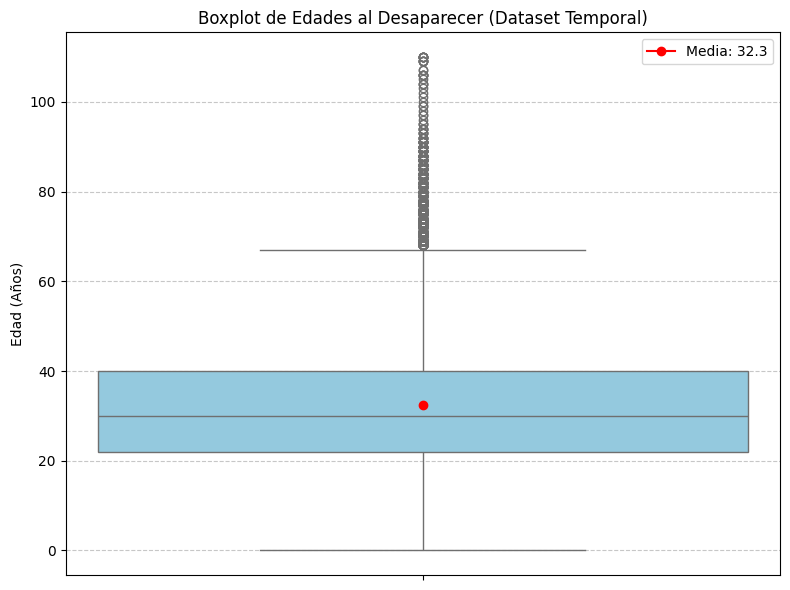

In [282]:

rango_e = edades_validas.max() - edades_validas.min()
q75, q25 = np.percentile(edades_validas, [75 ,25])
iqr_e = q75 - q25


print(f"--- Análisis de Variabilidad (Rango e IQR) ---")
print(f"Rango: {rango_e:.2f} años")
print(f"IQR: {iqr_e:.2f} años")
plt.figure(figsize=(8, 6))

# Creamos el boxplot
sns.boxplot(y=edades_validas, color="skyblue", width=0.4)

# Añadimos detalles estéticos y títulos
plt.title("Boxplot de Edades al Desaparecer (Dataset Temporal)")
plt.ylabel("Edad (Años)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Marcamos la media.
plt.plot(0, edades_validas.mean(), marker='o', color='red', label=f'Media: {edades_validas.mean():.1f}')

plt.legend()
plt.tight_layout()
plt.show()

Lo anterior es un boxplot, sabiendo el valor de IQR podemos dar un espacio en el cuál se pueden apreciar la concentración de nuestros registros, además de la detección de valores atípicos con los conocidos "whiskers" inferiores y superiores que son calculados mediante el IQR. Podemos observar la tendencia de edad en personas desaparecidas: Rangos de edad entre 20 y 40 años, lo cuál nos guía hacia un grupo de personas en su mayoría del genero masculino, por lo visto en las mediciones anteriores, que en su mayoría son adultos; pero antes de poder sacar conclusiones, es necesario revisar otras mediciones importantes como la varianza y la desviación estandar, las cuáles presentan la consistencia de información extraida en las edades.

De una manera un tanto coloquial, la desviación estandar nos indicará en que rango caen la mayoría de edades de gente desaparecida, mientras más grande sea la desviación, más grupos de edades se ven afectados por las desapariciones.


Varianza: 213.62
Desviación Estándar (σ): 14.62


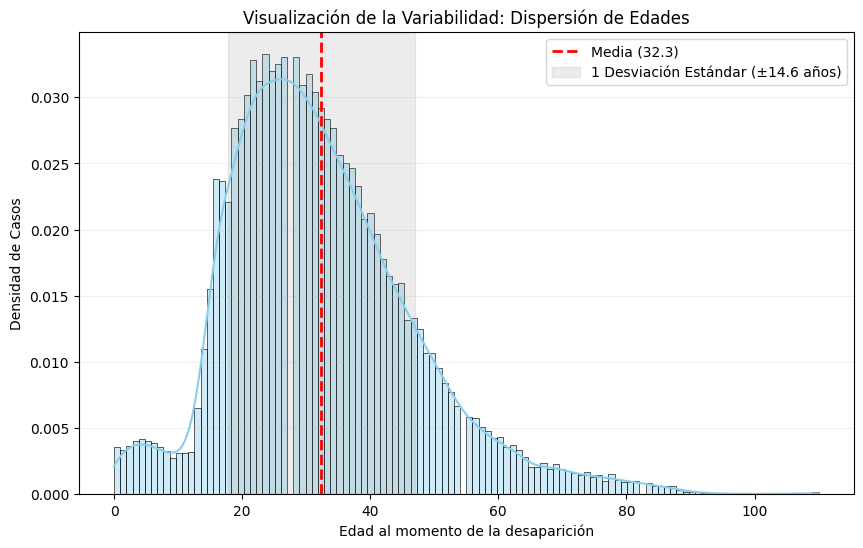

In [283]:
varianza_e = edades_validas.var()
std_e = edades_validas.std()
print(f"Varianza: {varianza_e:.2f}")
print(f"Desviación Estándar (σ): {std_e:.2f}")
plt.figure(figsize=(10, 6))

# Dibujamos la distribución (KDE es la línea de densidad)
sns.histplot(edades_validas, kde=True, color="skyblue", stat="density", alpha=0.4)

# Dibujamos la Media como eje central
plt.axvline(media_e, color="red", linestyle="--", linewidth=2, label=f"Media ({media_e:.1f})")

# Dibujamos las áreas de Desviación Estándar (±1 sigma)
plt.axvspan(media_e - std_e, media_e + std_e, color='gray', alpha=0.15,
            label=f"1 Desviación Estándar (±{std_e:.1f} años)")

plt.title("Visualización de la Variabilidad: Dispersión de Edades")
plt.xlabel("Edad al momento de la desaparición")
plt.ylabel("Densidad de Casos")
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

Después de calcular la varianza y la desviación, presentamos está gráfica que presenta conclusiones mucho más sólidas al respecto del grupo de edades, es claro ahora que en su mayoría las personas desaparecidas son mayores de edad, Pero también está gráfica nos permite "agrandar" un poco este grupo y llegar a una conclusión mucho más contundente: Las desapariciones afectan fuertemente a los adultos jovenes y los adolescentes, volviendo a las observaciones hechas en anteriores mediciones como los estados y sexo con más desapariciones, es muy probable que esto se deba a la delincuencia organizada, personas en rango de ser fuerza laboral se ven forzadas a unirse a estos grupos delictivos y sufrir las consecuencias que esto conlleva, esto es una conclusión bastante aventurad, ya que sería necesario una investigación más a fondo de la situación económica en estos lugares

##### Un pequeño agregado: Verificación de Limpieza

Esto es un pequeño agregado, ya que se consideró insuficiente solo el análisis de edad en el rubro anterior, así que aquí presentamos algo bastante interesante para nuestro trabajo:Hemos hecho correctamente nuestro proceso de limpieza. Si recordamos,la tabla con los registros generales contienen mucha más información que la temporal, pero en numerosas ocasiones se expresó la preocupación de tener información sesgada al no poseer consistencia en las fechas, mientras que en la tabla de registros temporal tenemos muchos menos registros, pero garantizamos un mejor proceso de limpieza con las edades.

¿Cómo podríamos representar el cambio entre ambas tablas?
A continuación tenemos la respuesta, recordemos que IQR y las Boxplots, además de la desviación estandar, ofrecen una manera de medir la consistencia de los registros. Claramente podemos ver la diferencia entre la tabla general y temporal al tener muchos más valores átipicos en el primero, además de valores de varianza y desviación estandar mucho más disparados que apuntan a sectores de edad mucho más grandes de forma inconsistente, mientras que la tabla temporal presenta unos whiskers ligeramente más centralizados que tienen mayor capacidad de detectar valores atípicos (Un ejemplo lo tenemos con la nula presencia de valores negativos) y una desviación más pequeña que focaliza mejor la información, la diferencia puede observarse en los Boxplots generados.


--- Medidas de Variabilidad: Edad (Dataset General) ---
Rango: 141.00 años
IQR (Rango Intercuartílico): 19.00 años
Varianza: 250.96
Desviación Estándar (σ): 15.84
-----------------------------------
--- Medidas de Variabilidad: Edad (Dataset Temporal) ---
Rango: 110.00 años
IQR (Rango Intercuartílico): 18.00 años
Varianza: 213.62
Desviación Estándar (σ): 14.62
-----------------------------------


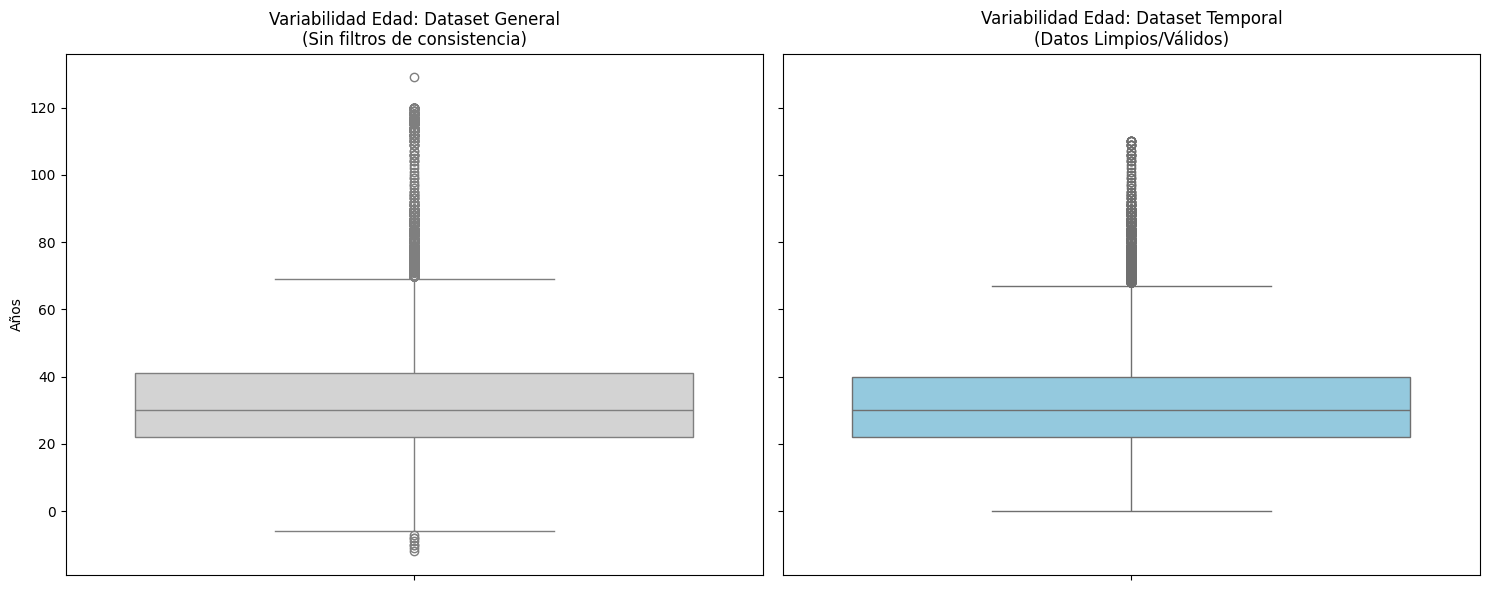

In [284]:



# Calculamos edad en el General (información sesgada)
f_nac_gen = pd.to_datetime(df_export_general['FECHA_NACIMIENTO_LIMPIA'], errors='coerce')
f_des_gen = pd.to_datetime(df_export_general['FECHA_DESAPARICION_LIMPIA'], errors='coerce')
edades_general = (f_des_gen.dt.year - f_nac_gen.dt.year).dropna()

# 'edades_validas' ya la tenemos del proceso anterior (Dataset Temporal Limpio)

def analizar_variabilidad_edad(datos, nombre):
    rango = datos.max() - datos.min()
    iqr = np.percentile(datos, 75) - np.percentile(datos, 25)
    varianza = datos.var()
    desviacion = datos.std()

    print(f"--- Medidas de Variabilidad: {nombre} ---")
    print(f"Rango: {rango:.2f} años")
    print(f"IQR (Rango Intercuartílico): {iqr:.2f} años")
    print(f"Varianza: {varianza:.2f}")
    print(f"Desviación Estándar (σ): {desviacion:.2f}")
    print("-" * 35)

# 2. Ejecutar comparativa
analizar_variabilidad_edad(edades_general, "Edad (Dataset General)")
analizar_variabilidad_edad(edades_validas, "Edad (Dataset Temporal)")

# 3. Visualización Comparativa con Boxplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Boxplot General
sns.boxplot(y=edades_general, ax=axes[0], color="lightgray")
axes[0].set_title("Variabilidad Edad: Dataset General\n(Sin filtros de consistencia)")
axes[0].set_ylabel("Años")

# Boxplot Temporal
sns.boxplot(y=edades_validas, ax=axes[1], color="skyblue")
axes[1].set_title("Variabilidad Edad: Dataset Temporal\n(Datos Limpios/Válidos)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Medidas de Heterogeneidad


Ahora se analizará con más detalle la proporción de reportes de desaparición por cada uno de los estados de la república para llegar a conclusiones importantes respecto a la proporción de los casos; ya sea que es una problemática generalizada en toda la república mexicana o solo es una preocupación que afecta a un solo grupo de estados.

Se puede dar el caso de aplicar estas medidas a los grupos de genero y edad al momento de desaparecer, pero ambas proporciones fueron extensamente evaluadas en las mediciones anteriores, además de que las gráficas de proporción de genero presentadas en las primeras secciones nos dan una idea concreta respecto a la distribución por edades, siendo ahora necesario ahondar en una sección no tan explorada con anterioridad.

Pasaremos a la tabla `df_export_general`para hacer nuestras evaluaciones, ya que en está ocasión requerimos de un panorama más general de la información.

#### Índice de impureza de Giny e índice de entropia de Shannon
Las siguientes medidas calculan la misma proporción pero de diferentes formas. Ambas emplean la misma escala para indicar la información de interés: Valores cercanos a 0 indican una alta concentración de los datos mientras que valores cercanos a 1 indican una distribución uniforme de cada uno de los registros. Al aplicar esto a los estados de la república podremos observar si la cantidadd de registros de desapariciones es una problemática generalizada en todo el país o solo un caso grave para unos cuantos estados.

La diferencia entre ambas mediciones radica en la definción y metodología, mientras que el índice de Giny mide diversidad, el índice de entropia mide incertidumbre, en este caso, el nivel de incertidumbre que se tiene al extraer un registro cualquiera y este pertenezca a una categoría u otra.

In [285]:


def calcular_indices_completos(serie):
    # 1. Proporciones
    proporciones = serie.value_counts(normalize=True)
    p = proporciones[proporciones > 0]
    n = len(p)

    # 2. Gini
    gini = 1 - np.sum(proporciones**2)

    # 3. Entropía de Shannon (H)
    h_shannon = -np.sum(p * np.log2(p))

    # 4. Entropía Normalizada (J' - Equidad de Pielou)
    h_max = np.log2(n)
    h_normalizada = h_shannon / h_max if n > 1 else 0

    return gini, h_shannon, h_normalizada, n, proporciones

entidades_limpias_gen = df_export_general[df_export_general['ENTIDAD'] != 'SE DESCONOCE']['ENTIDAD']

# Ejecutar
gini_e, h_sha_e, h_norm_e, n_e, dist_e = calcular_indices_completos(entidades_limpias_gen)

print(f"--- Análisis de Heterogeneidad: ENTIDAD  ---")
print(f"Número de categorías detectadas: {n_e}")
print(f"Índice de Gini: {gini_e:.4f}")
print(f"Entropía de Shannon (H): {h_sha_e:.4f}")
print(f"Entropía Normalizada (J'): {h_norm_e:.4f} (Equidad de Pielou)")

--- Análisis de Heterogeneidad: ENTIDAD  ---
Número de categorías detectadas: 32
Índice de Gini: 0.9399
Entropía de Shannon (H): 4.4048
Entropía Normalizada (J'): 0.8810 (Equidad de Pielou)


Para comparar directamente tanto Giny como Shannon debemos de normalizar la entropía, recordemos que la entropía maxíma de N disitribuciones es el logaritmo a base 2 de N. Por lo que para transformar la entropia en una escala de 0 a 1 debemos de dividr la entropia resultante por la máxima. esto es una medida adicional conocida como la **equidad de Pielou**.

Aquí observamos información reveladora para está investigación. Tanto el índice de Giny como el de Entropia son muy altos y cercanos al valor de 1 que indica diversidad máxima, esto nos indica que esto es un problema generalizado en todo el país al tener una distribución un tanto uniforme de los reportes.  

Esto se visualiza mejor al revisar la entropia por cada uno de los estados, en el siguiente gráfico podemos apreciar la probabilidad de que un registro cualquiera pertenezca a cada una de las entidades. Aplicamos una línea llamada **Distribución Uniforme Teórica** que señaliza la ubicación de las barras si tuvieramos una escala de entropia máxima.

Con esto podemos hacer una conclusión mucho más acertada de este fenómeno: Las despariciones son una problemática que asola de manera generalizada a todos los estados de la república, pero es una problemática aun más grave para un grupo específico de estados de la república; esto sive como base y un complemento contundente para las conclusiones hechas en secciones anteriores.


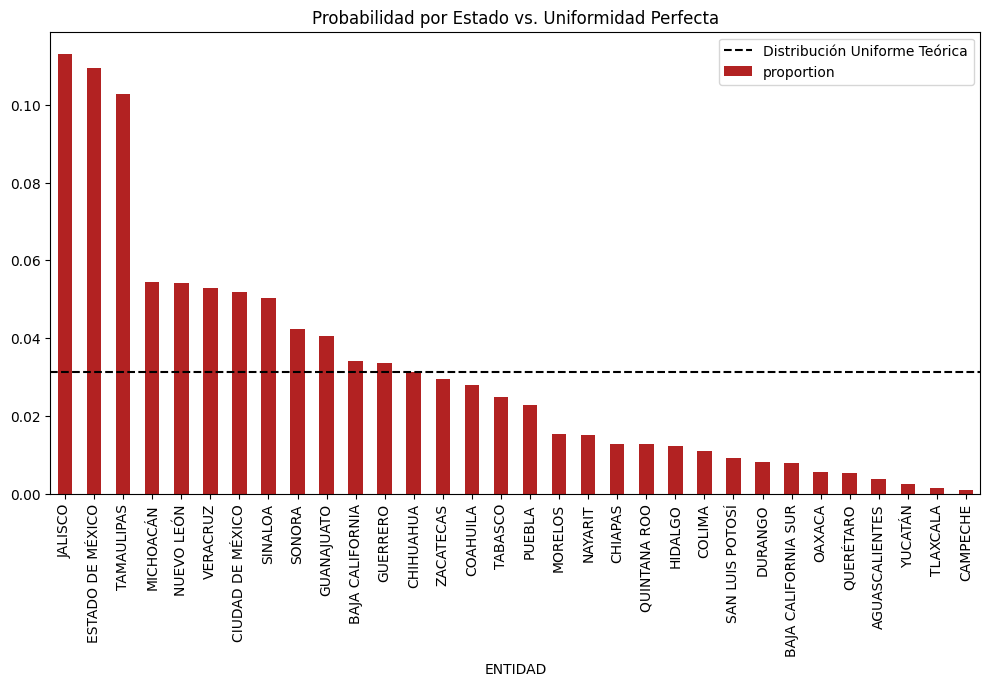

In [286]:
plt.figure(figsize=(12,6))
dist_e.plot(kind='bar', color='firebrick')
plt.axhline(1/32, color='black', linestyle='--', label='Distribución Uniforme Teórica')
plt.title("Probabilidad por Estado vs. Uniformidad Perfecta")
plt.legend()
plt.show()

### Medidas de Concentración

En esta sección volveremos a analizar el número de días de diferencia entre la desaparición y el registro de dicha desaparición que ahora denominaremos como **retraso**. Esto con el objetivo de conocer si la información de valores atípicos realmente está afectando las posibles conclusiones extraidas de estos días de retraso.

#### Índice de Concentración
La siguiente medición es una herramienta poderosa, ya que su principal función es indicar si unos pocos individuos (en este caso, los registros de desaparición) concentran la mayor cantidad de resultados (número de días de retraso), esto para determinar si existe un sesgo en nuestra información, ya que puede ser posible que generalmente las despariciones son registradas de manera inmediata pero existen unso pocos casos los cuáles se registran mucho después, logrando cambiar la percepción de eficiencia en los procesos de registro.

Para usar el índice de concentración debemos de definir el índice de acumulación de registros y el índice de acumulación de resultados, que tienen asignadas las nomenclaturas **Fi** y **Qi** respectivamente, que llevan el porcentaje de la información cargada al momento.

El indice de concentración **R** sería la suma de las diferencias de cada uno de los porcentajes por cada registro realizado, dandose un resultado entre la escala de 0 y 1 que indica el nivel de concentración (0 siendo una coenctración minima, resultados más equilibrados por cada registro mientras que 1 representa una concentración máxima: Unos pocos resultados acumulando la mayoría de resultados)

In [287]:


def calcular_indice_concentracion(datos):
    # 1. Ordenar datos de menor a mayor
    x = np.sort(datos)
    N = len(x)

    # 2. Calcular Fi (Proporción acumulada de unidades)
    # i / N para i desde 1 hasta N
    i = np.arange(1, N + 1)
    fi = i / N

    # 3. Calcular Qi (Proporción acumulada de la característica)
    # Suma acumulada de x / Suma total (N * media)
    qi = np.cumsum(x) / np.sum(x)

    # 4. Calcular R (Índice de concentración)
    # Solo sumamos hasta N-1
    numerador = np.sum(fi[:-1] - qi[:-1])
    denominador = np.sum(fi[:-1])
    R = numerador / denominador

    return R, fi, qi

# Aplicamos a los días de diferencia.
r_valor, fi_vals, qi_vals = calcular_indice_concentracion(dias_validos)

print(f"--- Índice de Concentración (R) ---")
print(f"Valor de R: {r_valor:.4f}")

--- Índice de Concentración (R) ---
Valor de R: 0.9955


Del resultado anterior podemos observar unw concentración de .9955, una concentración extremadamente alta que indica que unos pocos casos conservan el mayor número de resultados, esto aplicado a nuestro dataframe indica que unos pocos registros llevan la mayor cantidad de retrasos concentrada. Mientras que la mayoría de los reportes son realizados el mismo día pero los reportes con mayor tiempo de retraso sesgan nuestra información y por tanto, pueden llevar a conclusiones incorrectas.

Esto es más claro de observar en la siguiente **curva de Lorenz**, la distancia entre la línea de equidad perfecta con la proporción de días de retraso acumulados (Lo que demarca la curva rosa) demuestra el enorme sesgo que existe entre estos registros. O sea que un porcentaje muy pequeño de los reportes acumula la mayor cantidad de días de retraso.

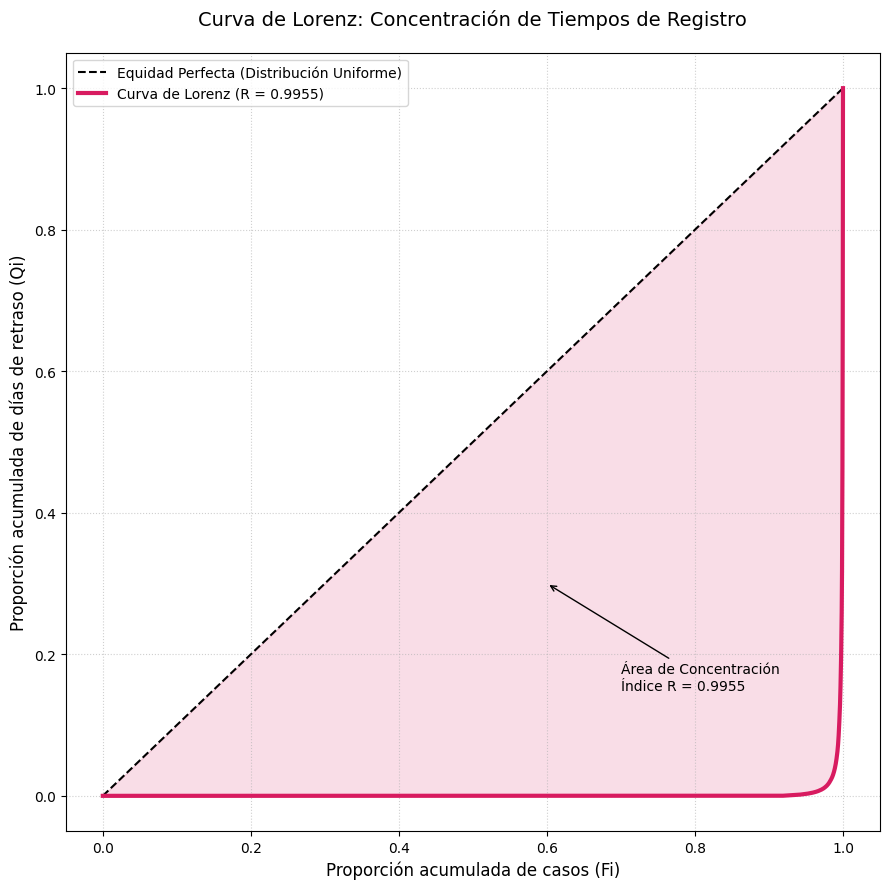

In [288]:


# 1. Preparación de los datos (Variable: días de diferencia)
datos_ordenados = np.sort(dias_validos.values)
n = len(datos_ordenados)

# Fi: Proporción acumulada de casos (eje X)
fi = np.arange(1, n + 1) / n

# Qi: Proporción acumulada de la característica (eje Y)
qi = np.cumsum(datos_ordenados) / np.sum(datos_ordenados)

fi = np.insert(fi, 0, 0)
qi = np.insert(qi, 0, 0)

# 4. Graficación
plt.figure(figsize=(9, 9))

# Línea de Equidad Perfecta (R = 0)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, label='Equidad Perfecta (Distribución Uniforme)')

# Curva de Lorenz
plt.plot(fi, qi, color='#D81B60', linewidth=3, label=f'Curva de Lorenz (R = {r_valor:.4f})')

# Sombreado del área de concentración
plt.fill_between(fi, fi, qi, color='#D81B60', alpha=0.15)

# Ajustes estéticos
plt.title("Curva de Lorenz: Concentración de Tiempos de Registro", fontsize=14, pad=20)
plt.xlabel("Proporción acumulada de casos (Fi)", fontsize=12)
plt.ylabel("Proporción acumulada de días de retraso (Qi)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

# Anotación técnica
plt.annotate(f'Área de Concentración\nÍndice R = {r_valor:.4f}', xy=(0.6, 0.3),
             xytext=(0.7, 0.15), arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

# Correlación

En está sección determinaremos si existe alguna relación entre los resultados de cada uno de nuestros registros tomando en cuenta el análisis expuesto en el apartado de cálculo de medidas.

Determinaremos si existe alguna relación a traves de la matriz de Pearson (La llamada matriz de correlación) entre la edad de la desaparición, el sexo de la persona y el tiempo de retraso que hubo para registrar el reporte de desaparición. Se ofrecerá una breve explicación de cada uno de los indices, además de clasificarlos como fuertes o debiles dependiendo del resultado.

In [289]:


# 1. Creamos un dataset específico para correlación
df_analisis = pd.DataFrame({
    'Edad': edades_validas,
    'Dias_Registro': dias_validos
})

# 2. Convertimos Sexo en variables numéricas (Dummies) para enriquecer la matriz
# Esto creará columnas como 'Sexo_HOMBRE' y 'Sexo_MUJER' con valores 0 y 1
sexo_dummies = pd.get_dummies(df_export_temporal['SEXO'], prefix='Sexo')
df_analisis = pd.concat([df_analisis, sexo_dummies], axis=1)

# 3. Calculamos la Matriz de Pearson
matriz_pearson = df_analisis.corr(method='pearson')

print("--- Matriz de Correlación de Pearson ---")
print(matriz_pearson)

--- Matriz de Correlación de Pearson ---
                        Edad  Dias_Registro  Sexo_HOMBRE  Sexo_INDETERMINADO  \
Edad                1.000000      -0.005283     0.207098            0.000555   
Dias_Registro      -0.005283       1.000000     0.003167            0.002442   
Sexo_HOMBRE         0.207098       0.003167     1.000000           -0.116585   
Sexo_INDETERMINADO  0.000555       0.002442    -0.116585            1.000000   
Sexo_MUJER         -0.207547      -0.003473    -0.988375           -0.035767   

                    Sexo_MUJER  
Edad                 -0.207547  
Dias_Registro        -0.003473  
Sexo_HOMBRE          -0.988375  
Sexo_INDETERMINADO   -0.035767  
Sexo_MUJER            1.000000  


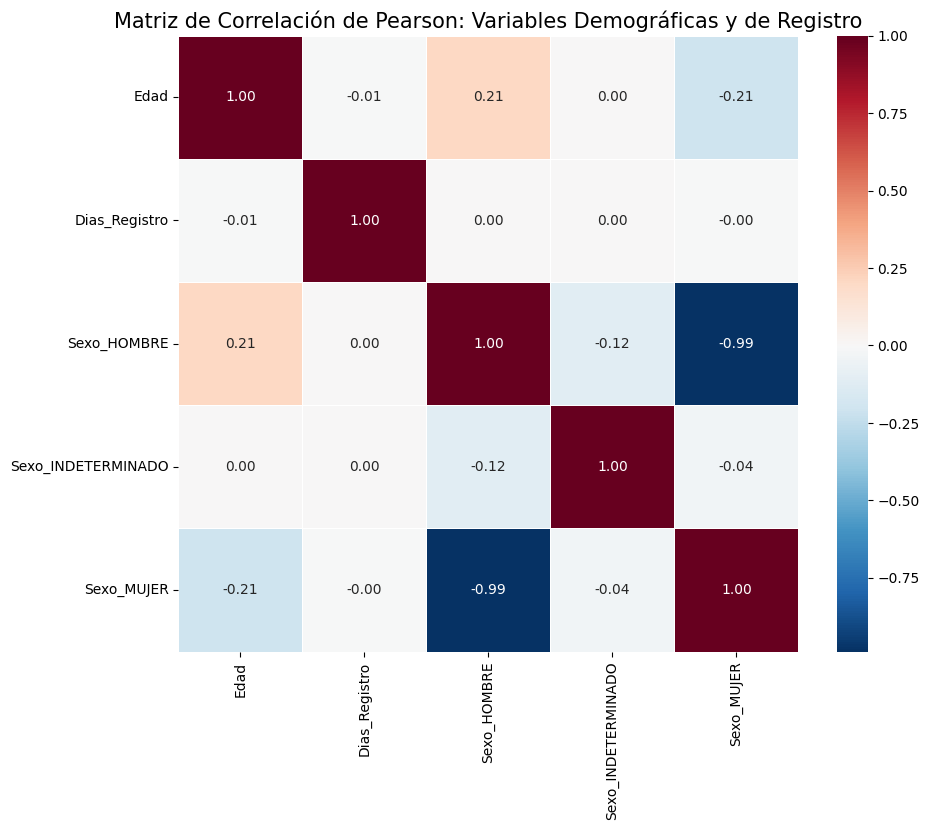

In [290]:
plt.figure(figsize=(10, 8))

# Dibujamos el heatmap
# annot=True pone los números dentro de los cuadros
sns.heatmap(matriz_pearson, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title("Matriz de Correlación de Pearson: Variables Demográficas y de Registro", fontsize=15)
plt.show()

Podemos observar que no tiene una relevancia real los días de retraso con cualquiera de los otros factores, aunque esto puede ser causado por el enorme sesgo de la variable.
En este caso no tenemos relaciones necesariamente fuertes, salvo la relación entre los generos, al tener un indice de -.99 entre Sexo_Hombre y Sexo_Mujer indica que el alza de uno es la disminución del otro, esto es obvio por la exclusión de pertenecer a alguna de las clasificaciones, o sea que si eres hombre no puedes pertencer a la clasificación de mujer y visceversa; lo mismo debería suceder con la clasificación de sexo indeterminado, pero al tener distintos procesos de limpieza en la tabla temporal esto difiere, pero mantiene el índice negativo.

Los únicos índices rescatables son la relación entre el género y la edad, mostrando una relación debil positiva y negativa para Sexo_Masculino y Sexo_Femenino respectivamente; indicando que las personas desaparecidas del géneo másculino tienden a tener más edad mientras que las personas del genero femenino suelen ser más jovenes.

Otra relación que consideramos importante notar es la relación entre el origen de los reportes y la probabilidad que se tiene que estos tenga información confidencial. Al solo querer evaluar la relación de origen entre reportes y confidencialidad, tendremos una matriz de correlación que solo relaciona un fenómeno: La confidencialidad.

Las relaciones debiles en este caso serían las que se encuentran en el centro de nuestro heatmap, donde no hay una relación clara entre ambos factores. Pero en los extremos tenemos relaciones un poco más fuertes tanto positivas como negativas. Las relaciones negativas representarían que hay mucha menos probabilidad que los datos sean confidenciales de ese origen de reporte (Liderando la Fiscalia de Chihuahua) mientras que un índice positivo representa que hay mayor probabilidad de que la información sea clasificada viniendo de ese origen.

Notamos en este apartado tanto a los orígenes de la Ciudad de México, del estado de Nuevo León y el estado de Jalisco; mientras que para las primeras dos cidudades es bastante probable que esto involucre algunos protocolos de seguridad o un tiempo de espera para desclasificar la información, es importante destacar que el estado lider en personas desaparecidas también tenga una alta probabilidad de tener la información confidencial.

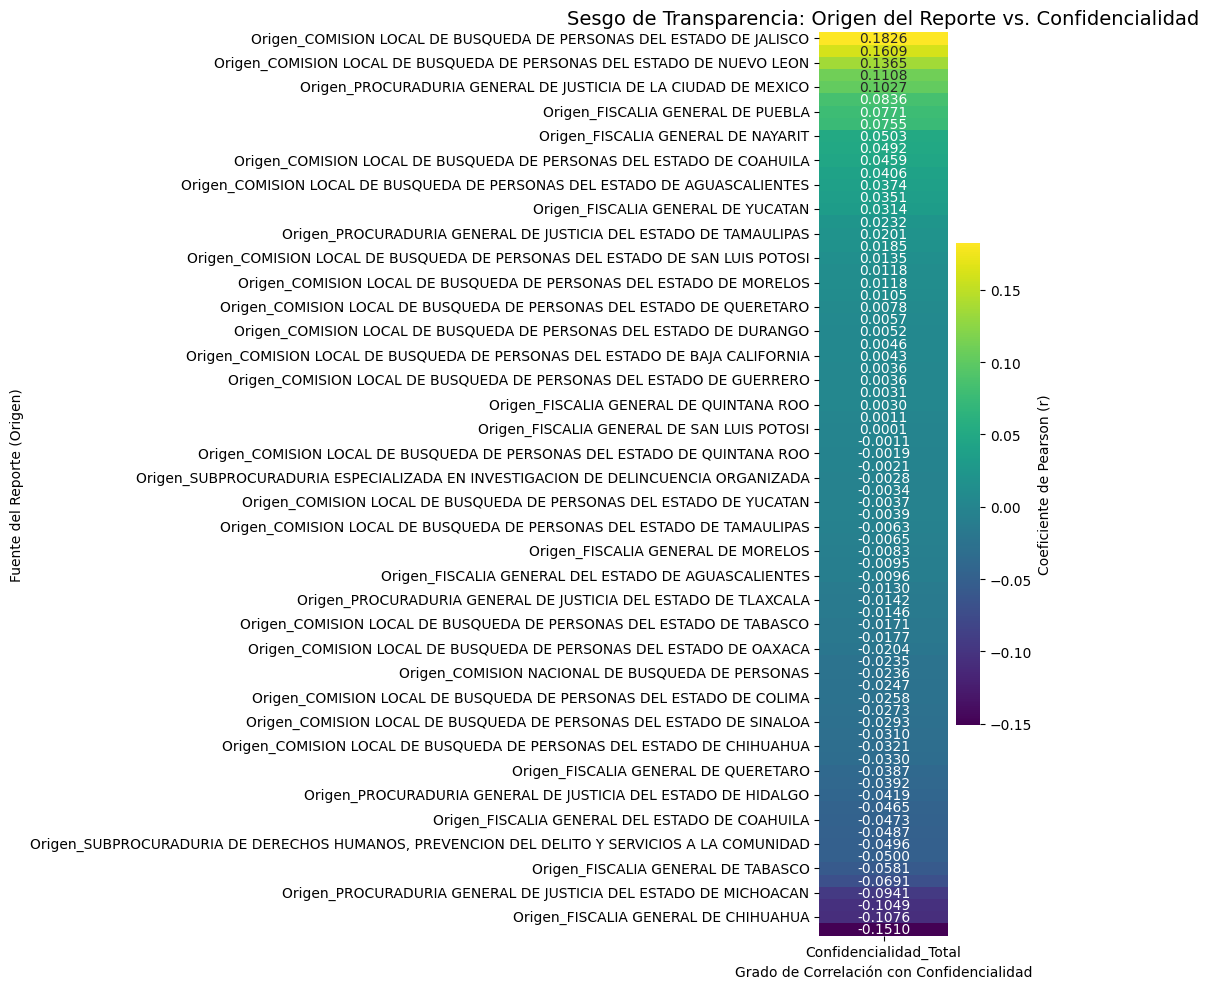

In [291]:


# 1. Selección de columnas necesarias
columnas_interes = ['ORIGEN_REPORTE', 'confidencial_con_estado', 'confidencial_sin_estado']
df_privacy = df_export_general[columnas_interes].copy()

# Si cualquiera de las dos es 1 (o True), la 'Confidencialidad_Total' será 1
df_privacy['Confidencialidad_Total'] = (
    (df_privacy['confidencial_con_estado'] == 1) |
    (df_privacy['confidencial_sin_estado'] == 1)
).astype(int)

# 3. Convertimos el ORIGEN_REPORTE en variables Dummies
origen_dummies = pd.get_dummies(df_privacy['ORIGEN_REPORTE'], prefix='Origen').astype(int)

# 4. Construimos el DataFrame de correlación final
# Solo nos interesa la variable unificada contra los orígenes
df_corr_final = pd.concat([df_privacy[['Confidencialidad_Total']], origen_dummies], axis=1)

# 5. Calculamos la Matriz de Pearson
matriz_privacidad = df_corr_final.corr(method='pearson')

# 6. Extraemos la correlación específica de la variable
analisis_origen = matriz_privacidad[['Confidencialidad_Total']].drop('Confidencialidad_Total').sort_values(by='Confidencialidad_Total', ascending=False)

# 7. Visualización
plt.figure(figsize=(10, 10))
sns.heatmap(analisis_origen, annot=True, cmap='viridis', fmt=".4f", cbar_kws={'label': 'Coeficiente de Pearson (r)'})

plt.title("Sesgo de Transparencia: Origen del Reporte vs. Confidencialidad", fontsize=14)
plt.ylabel("Fuente del Reporte (Origen)")
plt.xlabel("Grado de Correlación con Confidencialidad")
plt.tight_layout()
plt.show()